# Install & Import

In [ ]:
!pip install geopy pytz timezonefinder astral pyswarm wget

Defaulting to user installation because normal site-packages is not writeable


In [ ]:
import math
import wget
import datetime
import numpy as np
import pandas as pd
import seaborn as sns
from pyswarm import pso
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.integrate import dblquad
from scipy.optimize import minimize
from datetime import datetime, timedelta

In [ ]:
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

# Data Creation

In [ ]:
# hyper parameters
place_name = "Yazd, Iran"

# Constants based on the problem description
phi = (1 + np.sqrt(5)) / 2  # Golden ratio for Phyllotaxis
a_initial = 3.102  # Initial guess for 'a'
b_initial = 0.677  # Initial guess for 'b'
D_sep_initial = 300  # Initial guess for tower separation

# Cylinder receiver dimensions
D_r = 6      # meters (diameter)
H_r = 4      # meters (height)
cylinder_area = 2 * np.pi * D_r/2 * H_r

radius = D_r / 2  # meters (half of D_r)
height = H_r      # meters (H_r)

H_T = 140  # Tower height in meters
hight_tower = 140
hight_heliostat = 1.5

n_heliostats_per_field = 1000  # Number of heliostats per subfield
WH = 4  # Heliostat width in meters
LH = 6  # Heliostat length in meters
min_dist_heliostats = 2.5*np.sqrt(WH**2 + LH**2)  # Minimum distance between heliostats
min_distance = 30  # Minimum distance from the tower
max_distance = 1000 # max distance between heliostat and tower
heliostat_area = WH*LH

time_step_in_minutes             = 20
time_step_in_hours               = time_step_in_minutes/60

a = a_initial
b = b_initial
D_sep = D_sep_initial
n_heliostats = n_heliostats_per_field

G_max                            = 1  # Maximum solar irradiance (kW/m²)
power_consumption_per_degree_kWh = 0.003036  # energy consumption per degree of movement for each motor

In [ ]:
#finding location geographical properties

from geopy.geocoders import Nominatim
from timezonefinder import TimezoneFinder
from datetime import datetime
import pytz

def get_location_info(place_name):
    # Create a geocoder object
    geolocator = Nominatim(user_agent="location_finder")

    # Get location details
    location = geolocator.geocode(place_name)

    if location:
        latitude = location.latitude
        longitude = location.longitude

        # Use timezonefinder to get the timezone
        tf = TimezoneFinder()
        timezone_str = tf.timezone_at(lat=latitude, lng=longitude)

        if timezone_str:
            timezone = pytz.timezone(timezone_str)
            # Get UTC offset in hours
            utc_offset = timezone.utcoffset(datetime.now()).total_seconds() / 3600
        else:
            utc_offset = None

        return {
            'place_name': place_name,
            'latitude': latitude,
            'longitude': longitude,
            'utc_offset': utc_offset
        }
    else:
        return None

#############################################################################################################

# Example:
location_info = get_location_info("Yazd, Iran")

if location_info:
    print(f"Place: {location_info['place_name']}, Latitude: {location_info['latitude']}, Longitude: {location_info['longitude']}, UTC Offset: {location_info['utc_offset']}")
else:
    print("Location not found.")

Place: Yazd, Iran, Latitude: 32.0406164, Longitude: 54.6657189, UTC Offset: 3.5


In [ ]:
location_info = get_location_info("Yazd, Iran")

latitude   = location_info['latitude']
longitude  = location_info['longitude']
utc_offset = location_info['utc_offset']

In [ ]:
# finding location solar properties and creating a solar radiation dataset for a whole year in 1 minute time steps

MIN_SOLAR_ELEVATION_ANGLE = 0  # Sunrise/sunset occurs at SEA >= 0 degrees

def getSEA(latitude, longitude, utc_offset, hour, minute, day_of_year):
    hour_minute = (hour + minute / 60) - utc_offset
    g = (360 / 365.25) * (day_of_year + hour_minute / 24)
    g_radians = math.radians(g)

    # Calculate declination
    declination = (0.396372 -
                   22.91327 * math.cos(g_radians) +
                   4.02543 * math.sin(g_radians) -
                   0.387205 * math.cos(2 * g_radians) +
                   0.051967 * math.sin(2 * g_radians) -
                   0.154527 * math.cos(3 * g_radians) +
                   0.084798 * math.sin(3 * g_radians))

    # Time correction
    time_correction = (0.004297 +
                       0.107029 * math.cos(g_radians) -
                       1.837877 * math.sin(g_radians) -
                       0.837378 * math.cos(2 * g_radians) -
                       2.340475 * math.sin(2 * g_radians))

    SHA = (hour_minute - 12) * 15 + longitude + time_correction

    if SHA > 180:
        SHA_corrected = SHA - 360
    elif SHA < -180:
        SHA_corrected = SHA + 360
    else:
        SHA_corrected = SHA

    lat_radians = math.radians(latitude)
    d_radians = math.radians(declination)
    SHA_radians = math.radians(SHA)

    SZA_radians = math.acos(math.sin(lat_radians) * math.sin(d_radians) +
                             math.cos(lat_radians) * math.cos(d_radians) * math.cos(SHA_radians))

    SZA = math.degrees(SZA_radians)
    SEA = 90 - SZA

    return SEA

def getAZ(latitude, longitude, utc_offset, hour, minute, day_of_year):
    hour_minute = (hour + minute / 60) - utc_offset
    g = (360 / 365.25) * (day_of_year + hour_minute / 24)
    g_radians = math.radians(g)

    # Calculate declination
    declination = (0.396372 -
                   22.91327 * math.cos(g_radians) +
                   4.02543 * math.sin(g_radians) -
                   0.387205 * math.cos(2 * g_radians) +
                   0.051967 * math.sin(2 * g_radians) -
                   0.154527 * math.cos(3 * g_radians) +
                   0.084798 * math.sin(3 * g_radians))

    # Time correction
    time_correction = (0.004297 +
                       0.107029 * math.cos(g_radians) -
                       1.837877 * math.sin(g_radians) -
                       0.837378 * math.cos(2 * g_radians) -
                       2.340475 * math.sin(2 * g_radians))

    SHA = (hour_minute - 12) * 15 + longitude + time_correction

    if SHA > 180:
        SHA_corrected = SHA - 360
    elif SHA < -180:
        SHA_corrected = SHA + 360
    else:
        SHA_corrected = SHA

    lat_radians = math.radians(latitude)
    d_radians = math.radians(declination)
    SHA_radians = math.radians(SHA)

    SZA_radians = math.acos(math.sin(lat_radians) * math.sin(d_radians) +
                             math.cos(lat_radians) * math.cos(d_radians) * math.cos(SHA_radians))

    SZA = math.degrees(SZA_radians)

    cos_AZ = (math.sin(d_radians) - math.sin(lat_radians) * math.cos(SZA_radians)) / (
        math.cos(lat_radians) * math.sin(SZA_radians))

    AZ_rad = math.acos(cos_AZ)
    AZ = math.degrees(AZ_rad)

    return AZ

def sun_radiation_vector(AZ, SEA):
    sx = math.sin(math.radians(AZ)) * math.cos(math.radians(SEA))
    sy = math.cos(math.radians(AZ)) * math.cos(math.radians(SEA))
    sz = math.sin(math.radians(SEA))
    s = np.array([sx, sy, sz])
    return s

def calculate_solar_vectors(latitude, longitude, utc_offset):
    solar_vectors = []
    base_date = datetime(2024, 1, 1)  # January 1st of current year

    # Iterate through every day of the year
    for day_of_year in range(1, 366):
        sunrise = None
        sunset = None
        current_date = base_date + timedelta(days=day_of_year-1)

        # Find sunrise and sunset times
        for hour in range(24):
            for minute in range(60):
                SEA = getSEA(latitude, longitude, utc_offset, hour, minute, day_of_year)
                if SEA > MIN_SOLAR_ELEVATION_ANGLE and sunrise is None:
                    sunrise = (hour, minute)  # First time SEA > 0 is sunrise
                elif SEA < MIN_SOLAR_ELEVATION_ANGLE and sunrise is not None:
                    sunset = (hour, minute)  # First time SEA < 0 after sunrise is sunset
                    break
            if sunset:
                break

        # Calculate solar vectors only between sunrise and sunset
        for hour in range(sunrise[0], sunset[0] + 1):
            for minute in range(60):
                if (hour == sunrise[0] and minute < sunrise[1]) or (hour == sunset[0] and minute > sunset[1]):
                    continue  # Skip times outside sunrise-sunset range
                SEA = getSEA(latitude, longitude, utc_offset, hour, minute, day_of_year)
                if SEA >= MIN_SOLAR_ELEVATION_ANGLE:  # Calculate vectors only during the day
                    AZ = getAZ(latitude, longitude, utc_offset, hour, minute, day_of_year)
                    solar_vector = sun_radiation_vector(AZ, SEA)  # This is your numpy array
                    timestamp = current_date.replace(hour=hour, minute=minute)

                    # Combine solar vector with timestamp
                    row = np.concatenate([solar_vector, [timestamp]])
                    solar_vectors.append(row)

    return solar_vectors

In [ ]:
number_of_minutes_in_each_year = 365 * 24 * 60 # 525600
print("Number of minutes in each year:                          ", number_of_minutes_in_each_year)
print("Almost the number of minutes that sun is up in each year:", number_of_minutes_in_each_year/2)

Number of minutes in each year:                           525600
Almost the number of minutes that sun is up in each year: 262800.0


In [ ]:
solar_vectors = calculate_solar_vectors(latitude, longitude, utc_offset)
print(len(solar_vectors))

263590


In [ ]:
# solar vectors dataset creating

solar_vectors_df = pd.DataFrame(solar_vectors)
solar_vectors_df.columns = ['sx', 'sy', 'sz', 'time']
solar_vectors_df

,sx,sy,sz,time
0,0.886974,-0.461814,0.002375,2024-01-01 06:57:00
1,0.885888,-0.463864,0.005653,2024-01-01 06:58:00
2,0.884786,-0.465912,0.008927,2024-01-01 06:59:00
3,0.883667,-0.467958,0.012197,2024-01-01 07:00:00
4,0.882531,-0.470001,0.015463,2024-01-01 07:01:00
...,...,...,...,...
263585,0.881935,-0.471126,0.015195,2024-12-30 16:48:00
263586,0.883074,-0.469083,0.011933,2024-12-30 16:49:00
263587,0.884195,-0.467037,0.008666,2024-12-30 16:50:00
263588,0.885300,-0.464989,0.005395,2024-12-30 16:51:00


In [ ]:
# Sample Solar Vector
sample_solar_vector = solar_vectors_df.iloc[120*3, 0:3] # 120
print(sample_solar_vector)

sx    0.246624
sy   -0.801173
sz    0.545251
Name: 360, dtype: object


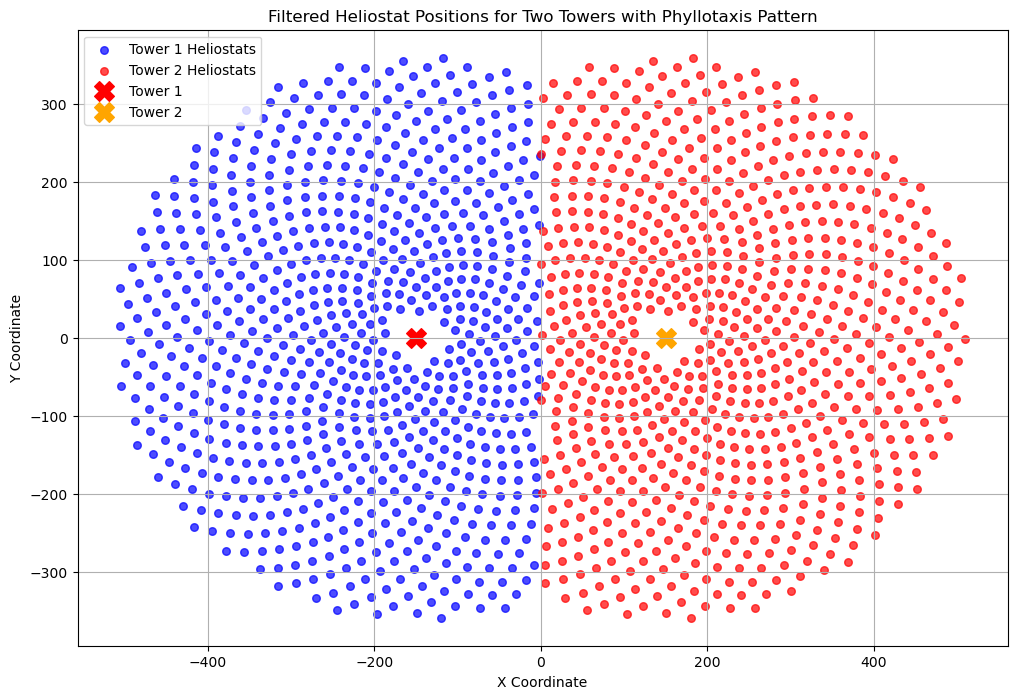

In [ ]:
# heliostat field layout defining

# Define the golden ratio
phi = (1 + np.sqrt(5)) / 2

########################################################################################################################
# Function to generate phyllotaxis points with a center gap and distance constraints3
def phyllotaxis_points(a, b, n_heliostats, min_distance, max_distance, min_dist_heliostats):
    angles = 2 * np.pi * phi ** 2 * np.arange(1, n_heliostats + 1)
    radii = min_distance + a * np.arange(1, n_heliostats + 1) ** b

    # Ensure the radii respect the max_distance constraint
    radii = np.clip(radii, min_distance, max_distance)

    x = radii * np.cos(angles)
    y = radii * np.sin(angles)

    # Apply the minimum distance between heliostats
    x_diff = np.diff(x)
    y_diff = np.diff(y)
    distances = np.sqrt(x_diff**2 + y_diff**2)
    valid_idx = np.insert(distances >= min_dist_heliostats, 0, True)  # Keep the first point

    return np.column_stack((x[valid_idx], y[valid_idx]))


# Initialize heliostats positions for both towers, including normal vectors
def initialize_heliostats(a, b, n_heliostats, D_sep, min_distance, max_distance, min_dist_heliostats, hight_heliostat, hight_tower):
    # Creating all the heliostats around each tower
    heliostats_tower1 = phyllotaxis_points(a, b, n_heliostats, min_distance, max_distance, min_dist_heliostats) - np.array([D_sep / 2, 0])
    heliostats_tower2 = phyllotaxis_points(a, b, n_heliostats, min_distance, max_distance, min_dist_heliostats) + np.array([D_sep / 2, 0])

    # Delete heliostats from tower 1 with x > 0
    heliostats_tower1 = heliostats_tower1[heliostats_tower1[:, 0] <= 0]
    # Delete heliostats from tower 2 with x < 0
    heliostats_tower2 = heliostats_tower2[heliostats_tower2[:, 0] >= 0]

    # Add z-coordinate (height of the heliostats)
    heliostats_tower1 = np.column_stack((heliostats_tower1, np.full(heliostats_tower1.shape[0], hight_heliostat)))
    heliostats_tower2 = np.column_stack((heliostats_tower2, np.full(heliostats_tower2.shape[0], hight_heliostat)))

    tower1_position = np.array([-D_sep / 2, 0, hight_tower])
    tower2_position = np.array([+D_sep / 2, 0, hight_tower])

    return heliostats_tower1, heliostats_tower2, tower1_position, tower2_position


###########################################################################################################

# Generate heliostat positions and normal vectors for both towers
heliostats_tower1, heliostats_tower2, tower1_position, tower2_position = initialize_heliostats(
    a_initial, b_initial, n_heliostats_per_field, D_sep, min_distance, max_distance, min_dist_heliostats, hight_heliostat, hight_tower
)

# Combine filtered heliostat positions for plotting (ignoring z for 2D plot)
filtered_positions = np.vstack((heliostats_tower1[:, :2], heliostats_tower2[:, :2]))

# Plotting
plt.figure(figsize=(12, 8))

# Plot filtered heliostats for tower 1
plt.scatter(heliostats_tower1[:, 0], heliostats_tower1[:, 1], s=30, color='blue', alpha=0.7, label='Tower 1 Heliostats')
# Plot filtered heliostats for tower 2
plt.scatter(heliostats_tower2[:, 0], heliostats_tower2[:, 1], s=30, color='red', alpha=0.7, label='Tower 2 Heliostats')
# Plot towers
plt.scatter(tower1_position[0], tower1_position[1], s=200, color='red', marker='X', label='Tower 1')  # Tower 1
plt.scatter(tower2_position[0], tower2_position[1], s=200, color='orange', marker='X', label='Tower 2')  # Tower 2
plt.title('Filtered Heliostat Positions for Two Towers with Phyllotaxis Pattern')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
#plt.axis('equal')  # Ensure aspect ratio is equal
plt.grid()
plt.legend()
plt.show()

In [ ]:
# heliostat positions dataset

heliostats_tower_1_df = pd.DataFrame(heliostats_tower1)
heliostats_tower_1_df.columns = ['x_h', 'y_h', 'z_h']

heliostats_tower_2_df = pd.DataFrame(heliostats_tower2)
heliostats_tower_2_df.columns = ['x_h', 'y_h', 'z_h']

heliostats_df = pd.concat([heliostats_tower_1_df, heliostats_tower_2_df], axis=0).reset_index(drop=True)
heliostats_df

,x_h,y_h,z_h
0,-174.408385,-22.360080,1.5
1,-146.943639,34.825655,1.5
2,-127.776109,-28.987130,1.5
3,-187.349521,6.606604,1.5
4,-116.905883,21.051768,1.5
...,...,...,...
1545,55.140937,-348.905845,1.5
1546,489.700873,-125.155447,1.5
1547,304.567430,327.866915,1.5
1548,257.564649,-346.383229,1.5


In [ ]:
heliostats_near_to_the_middle_of_the_field = heliostats_df[ (heliostats_df['x_h']<70) & (heliostats_df['x_h']>0) & (heliostats_df['y_h']<-200) & (heliostats_df['y_h']>-300) ]
heliostats_near_to_the_middle_of_the_field

,x_h,y_h,z_h
1185,50.417752,-203.599063,1.5
1209,64.022848,-220.205636,1.5
1224,32.561671,-211.945289,1.5
1248,46.596838,-229.496240,1.5
1263,13.895044,-218.510884,1.5
1272,62.817062,-245.942205,1.5
1286,28.237759,-237.109719,1.5
1309,44.813560,-254.624796,1.5
1324,9.065339,-243.039546,1.5
1333,63.520046,-270.819570,1.5


In [ ]:
#analyzed heliostat position and index
sample_heliostat = heliostats_df.iloc[1209] # 1063
sample_heliostat

x_h     64.022848
y_h   -220.205636
z_h      1.500000
Name: 1209, dtype: float64

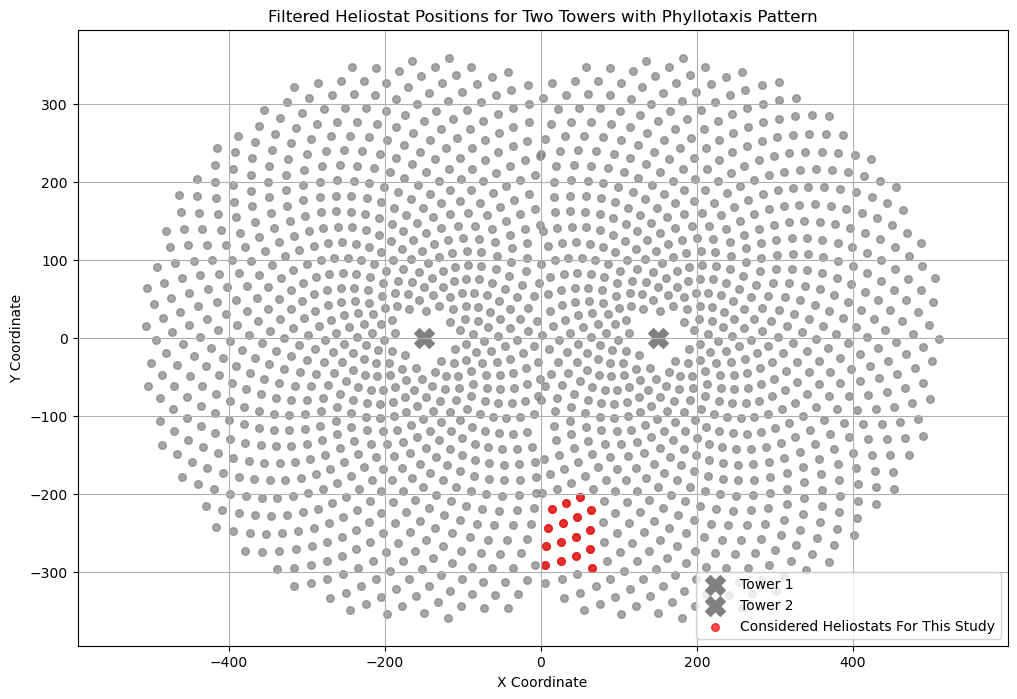

In [ ]:
# Plotting
plt.figure(figsize=(12, 8))

# Plot filtered heliostats for tower 1
plt.scatter(heliostats_tower1[:, 0], heliostats_tower1[:, 1], s=30, color='gray', alpha=0.7)
# Plot filtered heliostats for tower 2
plt.scatter(heliostats_tower2[:, 0], heliostats_tower2[:, 1], s=30, color='gray', alpha=0.7)
# Plot towers
plt.scatter(tower1_position[0], tower1_position[1], s=200, color='gray', marker='X', label='Tower 1')  # Tower 1
plt.scatter(tower2_position[0], tower2_position[1], s=200, color='gray', marker='X', label='Tower 2')  # Tower 2

# Highlight heliostats near the middle of the field
plt.scatter(heliostats_near_to_the_middle_of_the_field['x_h'],
            heliostats_near_to_the_middle_of_the_field['y_h'],
            s=30, color='red', alpha=0.7,
            label='Considered Heliostats For This Study')

# Add title, labels, grid, legend, and aspect ratio adjustment
plt.title('Filtered Heliostat Positions for Two Towers with Phyllotaxis Pattern')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.axis('equal')  # Ensure aspect ratio is equal
plt.grid()
plt.legend()
plt.show()

In [ ]:
# Tower positions
tower1_position = np.array([-150, 0, 140])
tower2_position = np.array([+150, 0, 140])

In [ ]:
# defining needed vectors

# tower vector (r) is a vector starting from the center of the reciever pointing to the center of analyzed heliostat

# Example heliostat position (you can loop through the heliostats to get their vectors)
# Let's assume we're calculating the vectors for the first heliostat from each tower
heliostat_position = np.array(sample_heliostat)  # Example heliostat position (x, y, z)

# Function to normalize a vector
def normalize_vector(vector):
    # Calculate the norm (magnitude) of the vector
    norm = np.linalg.norm(vector)

    # Check if the norm is zero to avoid division by zero
    if norm == 0:
        raise ValueError("Cannot normalize a zero vector")

    # Normalize the vector by dividing by its norm
    normalized_vector = vector / norm
    return normalized_vector

# Function to calculate r1 (tower 1 to heliostat) and r2 (tower 2 to heliostat)
def calculate_r_vectors(tower1_position, tower2_position, heliostat_position):
    r1 = heliostat_position - tower1_position  # Vector from tower 1 to heliostat
    r2 = heliostat_position - tower2_position  # Vector from tower 2 to heliostat

    # Normalize the vectors
    r1_normalized = normalize_vector(r1)
    r2_normalized = normalize_vector(r2)

    return r1, r2, r1_normalized, r2_normalized

# Calculate the vectors and their normalized versions for the given heliostat position
r1, r2, r1_normalized, r2_normalized = calculate_r_vectors(tower1_position, tower2_position, heliostat_position)

# Print the results
print(f"Vector r1 (from Tower 1 to Heliostat): {r1}")
print(f"Normalized Vector r1: {r1_normalized}")
print(f"Vector r2 (from Tower 2 to Heliostat): {r2}")
print(f"Normalized Vector r2: {r2_normalized}")

Vector r1 (from Tower 1 to Heliostat): [ 214.0228477  -220.20563593 -138.5       ]
Normalized Vector r1: [ 0.63533568 -0.65368954 -0.41114298]
Vector r2 (from Tower 2 to Heliostat): [ -85.9771523  -220.20563593 -138.5       ]
Normalized Vector r2: [-0.31380855 -0.80372993 -0.50551202]


In [ ]:
# Function to calculate the heliostat normal vector
def calculate_heliostat_normal(s, r):
    # Calculate the sum of the sun vector and the normalized tower vector
    vector_sum = s[0:3] + r
    # Normalize the resulting vector to get the heliostat normal vector
    normal_vector = normalize_vector(vector_sum)
    return normal_vector

# Example sun vector (assuming sun is directly overhead at zenith position)
s = np.array(sample_solar_vector)  # Example sun vector pointing directly downwards

# Calculate the tower vectors r1 and r2, and their normalized versions
r1, r2, r1_normalized, r2_normalized = calculate_r_vectors(tower1_position, tower2_position, heliostat_position)

# Calculate the heliostat normal vector for both towers
heliostat_normal_vector_tower1 = calculate_heliostat_normal(s, r1_normalized)
heliostat_normal_vector_tower2 = calculate_heliostat_normal(s, r2_normalized)

# Print the results
print(f"Heliostat Normal Vector if pointed at Tower 1: {heliostat_normal_vector_tower1}")
print(f"Heliostat Normal Vector if pointed at Tower 2: {heliostat_normal_vector_tower2}")

Heliostat Normal Vector if pointed at Tower 1: [0.5167954637921401 -0.8524947367847753 0.07858226490833363]
Heliostat Normal Vector if pointed at Tower 2: [-0.04181245512281617 -0.9988193324512119 0.024731755261568816]


In [ ]:
def calculate_angle_between_vectors(vec1, vec2):

    dot_product = np.dot(vec1, vec2)


    # Calculate the cosine of the angle
    cos_angle = dot_product

    # Calculate the angle in radians and convert to degrees
    angle_rad = np.arccos(np.clip(cos_angle, -1.0, 1.0))
    angle_deg = np.degrees(angle_rad)

    return angle_deg

############################################################################################
#example

print(calculate_angle_between_vectors(heliostat_normal_vector_tower1, r1_normalized))
print(calculate_angle_between_vectors(heliostat_normal_vector_tower1, np.array(sample_solar_vector)))

# since these two angles are equal so every thing works properly

31.42790492709134
31.42790492709134


In [ ]:
# defining a function to calculate distance between two points in 3D space

import numpy as np
def calculate_distance(point1, point2):
    point1 = np.array(point1)
    point2 = np.array(point2)
    distance = np.linalg.norm(point2 - point1)
    return distance

##############################################################################
# d is the distance between analyzed heliostat and tower (tower1 or tower2)

d1 = calculate_distance(sample_heliostat, tower1_position)
d2 = calculate_distance(sample_heliostat, tower2_position)

print(d1)
print(d2)

336.8657765847771
273.97963941136203


# Eta Calculation  

## Eta Attenuation

In [ ]:
# calculation attenuation efficiency of analyzed heliostat

def attenuation_efficiency(d): #
    return 0.993321 - 0.0001176*d + 1.97 * (10 ** -8) * (d ** 2)

attenuation_efficiency_1 = attenuation_efficiency(d1)
attenuation_efficiency_2 = attenuation_efficiency(d2)

################################################################################
print(f" attenuation efficiency if pointed at tower1 : {attenuation_efficiency(d1)}")
print(f" attenuation efficiency if pointed at tower2 : {attenuation_efficiency(d2)}")

 attenuation efficiency if pointed at tower1 : 0.9559411121368813
 attenuation efficiency if pointed at tower2 : 0.9625797718086198


## Eta Reflectivity

In [ ]:
# calculating reflection efficiency for analyzed heliostat
# no different between pointing to each tower , this value is constanent

def reflectivity_efficiency():
    return 0.88*0.95

reflection_efficiency_1 = reflectivity_efficiency()
reflection_efficiency_2 = reflectivity_efficiency()

################################################################################
print(f"reflection efficiency of the analyzed heliostat if pointed at tower 1 : {reflection_efficiency_1}")
print(f"reflection efficiency of the analyzed heliostat if pointed at tower 2 : {reflection_efficiency_2}")

reflection efficiency of the analyzed heliostat if pointed at tower 1 : 0.836
reflection efficiency of the analyzed heliostat if pointed at tower 2 : 0.836


## Eta Cosine

In [ ]:
# calculating cosine efficiency for analyzed heliostat

def cosine_efficiency(heliostat_normal_vector, sun_vector):
    return np.dot(heliostat_normal_vector, sun_vector)

cosine_efficiency_1 = cosine_efficiency(heliostat_normal_vector_tower1, np.array(sample_solar_vector))
cosine_efficiency_2 = cosine_efficiency(heliostat_normal_vector_tower2, np.array(sample_solar_vector))

################################################################################
print(f" cosine_efficiency if pointed at tower1 : {cosine_efficiency_1}")
print(f" cosine_efficiency if pointed at tower2 : {cosine_efficiency_2}")

 cosine_efficiency if pointed at tower1 : 0.8532969472451888
 cosine_efficiency if pointed at tower2 : 0.8033998966927461


## Eta Interception

In [ ]:
omega1 = calculate_angle_between_vectors(heliostat_normal_vector_tower1, sample_solar_vector)
omega2 = calculate_angle_between_vectors(heliostat_normal_vector_tower2, sample_solar_vector)

################################################################################
print(f"omega angle if pointed at tower1 : {omega1}")
print(f"omega angle if pointed at tower2 : {omega2}")

omega angle if pointed at tower1 : 31.42790492709134
omega angle if pointed at tower2 : 36.543993825115436


In [ ]:
def interception_efficiency(sun_vector, heliostat_normal_vector, W_H, L_H, f, D):

    sigma_sun = 2.51e-3  # converting to radians (mrad to rad)
    sigma_bq  = 1.88e-3  # converting to radians (mrad to rad)
    sigma_tr  = 0.63e-3  # converting to radians (mrad to rad)

    omega   = calculate_angle_between_vectors(heliostat_normal_vector, sample_solar_vector)
    epsilon = np.deg2rad(omega)

    H_t = np.sqrt(W_H * L_H) * abs((D / f) - np.cos(epsilon))
    W_s = np.sqrt(W_H * L_H) * abs((D / f) * np.cos(epsilon) - 1)

    sigma_ast = np.sqrt((0.5 * (H_t**2 + W_s**2 ))) / (4 * D)
    sigma_tot = np.sqrt(D**2 * (sigma_sun**2 + sigma_bq**2 + sigma_ast**2 + sigma_tr**2))

    def integrand(y, x, sigma_tot):
        return np.exp((-x**2 - y**2) / (2 * sigma_tot**2))

    def calculate_eta_int(sigma_tot):
        coefficient = 1 / (2 * np.pi * sigma_tot**2)
        integral_result, error = dblquad(
        integrand,
        -radius, radius,            # x limits from -8 to 8
        lambda x: -2, lambda x: 2,  # y limits from 0 to 24
        args=(sigma_tot,))
        Interception_efficiency = coefficient * integral_result
        return Interception_efficiency

    return calculate_eta_int(sigma_tot)

################################################################################
Interception_efficiency_1 = interception_efficiency(sample_solar_vector, heliostat_normal_vector_tower1, WH, LH, d2, d1)
Interception_efficiency_2 = interception_efficiency(sample_solar_vector, heliostat_normal_vector_tower2, WH, LH, d2, d2)

print("Interception efficiency if pointing at tower 1:", Interception_efficiency_1)
print("Interception efficiency if pointing at tower 2:", Interception_efficiency_2)

Interception efficiency if pointing at tower 1: 0.9170125805651922
Interception efficiency if pointing at tower 2: 0.9712986362218355


## Eta Shadowing & Blocking

In [ ]:
# Finding 10 closest heliostats to the analyzed heliostat
def calculate_distance(heliostat1, heliostat2):
    return np.linalg.norm(heliostat1[['x_h', 'y_h', 'z_h']].values - heliostat2[['x_h', 'y_h', 'z_h']].values)

# Function to find closest heliostats to the analyzed heliostat
def find_closest_heliostats(analyzed_heliostat, heliostats_df, top_n=10):

    # Calculate distance of all heliostats to the analyzed heliostat
    distances = heliostats_df[['x_h', 'y_h', 'z_h']].apply(lambda row: calculate_distance(analyzed_heliostat, row), axis=1)
    closest_indices = distances[distances > 0].nsmallest(top_n).index
    return heliostats_df.loc[closest_indices]

################################################################################
closest_heliostats = find_closest_heliostats(sample_heliostat, heliostats_df, top_n=5)
closest_heliostats

,x_h,y_h,z_h
1169,80.393567,-209.236683,1.5
1248,46.596838,-229.496240,1.5
1185,50.417752,-203.599063,1.5
1233,79.775757,-235.687927,1.5
1272,62.817062,-245.942205,1.5


In [ ]:
def calculate_solid_angle(projection_vector, WH = WH, LH = LH):
    """
    Approximate the solid angle subtended by a neighbor heliostat at the target heliostat's position.
    This method assumes the heliostat is roughly rectangular.
    """
    distance = np.linalg.norm(projection_vector)
    if distance == 0:
        return 0  # Avoid division by zero if the neighbor and target heliostat positions are the same.

    heliostat_area = WH * LH
    solid_angle = heliostat_area / (distance ** 2)  # Approximate solid angle in steradians

    return solid_angle

################################################################################
projection_vector = closest_heliostats - sample_heliostat
solid_angle = calculate_solid_angle(projection_vector)

print("Solid angle: ", solid_angle)

Solid angle:  0.010038242333350357


In [ ]:
# Function to calculate r (tower to heliostat)
def calculate_r_vector(tower_position, heliostat_position):
    r = heliostat_position - tower_position
    r_normalized = normalize_vector(r)
    return r_normalized

################################################################################
print("Tower vector 1:", calculate_r_vector(tower1_position, sample_heliostat))
print("Tower vector 2:", calculate_r_vector(tower2_position, sample_heliostat))

Tower vector 1: x_h    0.635336
y_h   -0.653690
z_h   -0.411143
Name: 1209, dtype: float64
Tower vector 2: x_h   -0.313809
y_h   -0.803730
z_h   -0.505512
Name: 1209, dtype: float64


In [ ]:
def shading_and_blocking_efficiency(sample_heliostat,
                                    heliostats_df,
                                    sun_vector,
                                    tower_position, W_H = WH, L_H = LH, top_n=10):

    closest_heliostats = find_closest_heliostats(sample_heliostat, heliostats_df, top_n)

    heliostat_area = W_H * L_H

    # tower vector
    r_normalized = calculate_r_vector(tower_position, sample_heliostat)

    # Initialize shaded and blocked area counters
    shaded_area  = 0
    blocked_area = 0

    # Solid angle approximation for shadow and blocking overlap avoidance
    projection_vector = closest_heliostats - sample_heliostat
    solid_angle = calculate_solid_angle(projection_vector, W_H, L_H)

    for _, neighbor in closest_heliostats.iterrows():
        neighbor_position = neighbor[['x_h', 'y_h', 'z_h']]

        # Calculate the projection vector from the neighbor heliostat to the current heliostat
        projection_vector = neighbor_position - sample_heliostat

        # Shading calculation based on sun vector
        shading_angle_cos = np.dot(projection_vector, sun_vector) / (np.linalg.norm(projection_vector) * np.linalg.norm(sun_vector))
        shading_efficiency = max(0, 1 - shading_angle_cos)  # Angle-based shading efficiency

        #print('shading_efficiency', shading_efficiency)

        # Blocking calculation based on tower vector
        blocking_angle_cos = np.dot(projection_vector, r_normalized) / (np.linalg.norm(projection_vector) * np.linalg.norm(r_normalized))
        blocking_efficiency = max(0, 1 - blocking_angle_cos)  # Angle-based blocking efficiency

        #print('blocking_efficiency', blocking_efficiency)

        # Approximate the shaded or blocked area considering the solid angle
        shaded_area  += heliostat_area * shading_efficiency  * solid_angle
        blocked_area += heliostat_area * blocking_efficiency * solid_angle

        #print('heliostat_area', heliostat_area, 'shading_efficiency', shading_efficiency, 'solid_angle', solid_angle)
        #print(shaded_area)
        #print(blocked_area)

    # Cap shaded and blocked areas to avoid exceeding the heliostat area
    shaded_area  = min(shaded_area , heliostat_area)
    blocked_area = min(blocked_area, heliostat_area)

    # Calculate shading and blocking efficiencies
    eta_shading  = (heliostat_area - shaded_area ) / heliostat_area
    eta_blocking = (heliostat_area - blocked_area) / heliostat_area

    # Combine shading and blocking efficiencies into a single efficiency
    eta_s_and_b = eta_shading * eta_blocking

    #print(eta_shading)
    #print(eta_blocking)

    return eta_s_and_b

################################################################################
Shadowing_and_Blocking_Efficiency_1 = shading_and_blocking_efficiency(sample_heliostat, heliostats_df, sample_solar_vector, tower1_position)
Shadowing_and_Blocking_Efficiency_2 = shading_and_blocking_efficiency(sample_heliostat, heliostats_df, sample_solar_vector, tower2_position)

print(f"Shadowing_and_Blocking_Efficiency_1:", Shadowing_and_Blocking_Efficiency_1)
print(f"Shadowing_and_Blocking_Efficiency_2:", Shadowing_and_Blocking_Efficiency_2)

Shadowing_and_Blocking_Efficiency_1: 0.9439859947546917
Shadowing_and_Blocking_Efficiency_2: 0.9427962653153231


## Eta total

In [ ]:
print('attenuation_efficiency_1 ', attenuation_efficiency_1           , '\tattenuation_efficiency_2 ', attenuation_efficiency_2)
print('cosine_efficiency_1      ', cosine_efficiency_1                , '\tcosine_efficiency_2      ', cosine_efficiency_2)
print('interception_efficiency_1', Interception_efficiency_1          , '\tinterception_efficiency_2', Interception_efficiency_2)
print('s_&_b_Efficiency_1       ', Shadowing_and_Blocking_Efficiency_1, '\ts_b_Efficiency_2         ', Shadowing_and_Blocking_Efficiency_2)

attenuation_efficiency_1  0.9559411121368813 	attenuation_efficiency_2  0.9625797718086198
cosine_efficiency_1       0.8532969472451888 	cosine_efficiency_2       0.8033998966927461
interception_efficiency_1 0.9170125805651922 	interception_efficiency_2 0.9712986362218355
s_&_b_Efficiency_1        0.9439859947546917 	s_b_Efficiency_2          0.9427962653153231


In [ ]:
# calculating total efficiency for analyzed heliostat in both directions toward tower 1 and tower 2

total_efficiency_1 = attenuation_efficiency_1*reflection_efficiency_1* cosine_efficiency_1*Interception_efficiency_1* Shadowing_and_Blocking_Efficiency_1
total_efficiency_2 = attenuation_efficiency_2*reflection_efficiency_2* cosine_efficiency_2*Interception_efficiency_2* Shadowing_and_Blocking_Efficiency_2

print(f"total efficiency of the analyzed heliostat if pointed at tower 1 : {total_efficiency_1}")
print(f"total efficiency of the analyzed heliostat if pointed at tower 2 : {total_efficiency_2}")

total efficiency of the analyzed heliostat if pointed at tower 1 : 0.5903077077313021
total efficiency of the analyzed heliostat if pointed at tower 2 : 0.5920323147612114


In [ ]:
# calculating heliostat total efficiency if it is pointing at tower 1

def caclculate_total_efficiency(heliostat_normal_vector, solar_vector, tower_position, sample_heliostat=sample_heliostat, heliostats_df=heliostats_df, d1=d1, d2=d2, W_H=WH, L_H=LH):

    f = d1 if d1<d2 else d2
    D = d1 if tower_position[0]<0 else d2

    reflection_eta             = reflectivity_efficiency()
    attenuation_eta            = attenuation_efficiency(D)
    cosine_eta                 = cosine_efficiency(heliostat_normal_vector, solar_vector)
    interception_eta           = interception_efficiency(solar_vector, heliostat_normal_vector, W_H, L_H, f, D)
    shadowing_and_blocking_eta = shading_and_blocking_efficiency(sample_heliostat, heliostats_df, solar_vector, tower_position)

    total_efficiency = reflection_eta * attenuation_eta * cosine_eta * interception_eta * shadowing_and_blocking_eta

    return  total_efficiency

################################################################################
print( 'caclculate_total_efficiency 1:', caclculate_total_efficiency(heliostat_normal_vector_tower1, sample_solar_vector, tower1_position) )
print( 'caclculate_total_efficiency 2:', caclculate_total_efficiency(heliostat_normal_vector_tower2, sample_solar_vector, tower2_position) )

caclculate_total_efficiency 1: 0.5903077077313021
caclculate_total_efficiency 2: 0.5920323147612114


# Economic Optimization


## Functions (Energy Production)

In [ ]:
solar_vectors_df.iloc[0]['time']

Timestamp('2024-01-01 06:57:00')

In [ ]:
# Calculates the angle of the sun above the horizon based on the current time, day of the year, and latitude.

def solar_elevation_angle(timestamp,   # Current time
                          latitude     # Geographic latitude of the heliostat location.
                          ):

    day_of_year = timestamp.day

    # Position of the sun in the sky relative to noon.
    hour_angle = (timestamp.hour + timestamp.minute / 60) * 15 - 180

    # The tilt of the Earth relative to the sun for the given day.
    declination = 23.45 * math.sin(math.radians(360 * (284 + day_of_year) / 365))


    elevation_angle = math.degrees(
        math.asin(math.sin(math.radians(latitude)) * math.sin(math.radians(declination)) +
                  math.cos(math.radians(latitude)) * math.cos(math.radians(declination)) * math.cos(math.radians(hour_angle))))

    return max(0, elevation_angle)

################################################################################

sample_solar_vector_1  = solar_vectors_df.iloc[  0]
sample_solar_vector_2  = solar_vectors_df.iloc[120]
sample_solar_vector_3  = solar_vectors_df.iloc[240]
sample_solar_vector_4  = solar_vectors_df.iloc[360]
sample_solar_vector_5  = solar_vectors_df.iloc[480]
sample_solar_vector_6  = solar_vectors_df.iloc[600]

sea_1 = solar_elevation_angle( sample_solar_vector_1['time'], latitude )
sea_2 = solar_elevation_angle( sample_solar_vector_2['time'], latitude )
sea_3 = solar_elevation_angle( sample_solar_vector_3['time'], latitude )
sea_4 = solar_elevation_angle( sample_solar_vector_4['time'], latitude )
sea_5 = solar_elevation_angle( sample_solar_vector_5['time'], latitude )
sea_6 = solar_elevation_angle( sample_solar_vector_6['time'], latitude )

print('solar_elevation_angle_1:', sea_1)
print('solar_elevation_angle_2:', sea_2)
print('solar_elevation_angle_3:', sea_3)
print('solar_elevation_angle_4:', sea_4)
print('solar_elevation_angle_5:', sea_5)
print('solar_elevation_angle_6:', sea_6)

solar_elevation_angle_1: 0
solar_elevation_angle_2: 19.69660548669424
solar_elevation_angle_3: 32.92467552583098
solar_elevation_angle_4: 33.28626952912878
solar_elevation_angle_5: 20.578017866604615
solar_elevation_angle_6: 0


In [ ]:
def calculate_irradiance(elevation_angle):
    return G_max * math.sin(math.radians(elevation_angle))

################################################################################

radiance_1 = calculate_irradiance(sea_1)
radiance_2 = calculate_irradiance(sea_2)
radiance_3 = calculate_irradiance(sea_3)
radiance_4 = calculate_irradiance(sea_4)
radiance_5 = calculate_irradiance(sea_5)
radiance_6 = calculate_irradiance(sea_6)

print('calculate_irradiance_1:', radiance_1)
print('calculate_irradiance_2:', radiance_2)
print('calculate_irradiance_3:', radiance_3)
print('calculate_irradiance_4:', radiance_4)
print('calculate_irradiance_5:', radiance_5)
print('calculate_irradiance_6:', radiance_6)

calculate_irradiance_1: 0.0
calculate_irradiance_2: 0.33703948000077677
calculate_irradiance_3: 0.5435359979571192
calculate_irradiance_4: 0.5488225077507056
calculate_irradiance_5: 0.35148249335156545
calculate_irradiance_6: 0.0


In [ ]:
r1_normalized = calculate_r_vector(tower1_position, sample_heliostat)
r2_normalized = calculate_r_vector(tower2_position, sample_heliostat)

print('r1_normalized:', r1_normalized.values)
print('r2_normalized:', r2_normalized.values)

r1_normalized: [ 0.63533568 -0.65368954 -0.41114298]
r2_normalized: [-0.31380855 -0.80372993 -0.50551202]


In [ ]:
heliostat_normal_vector_tower1_1 = calculate_heliostat_normal(sample_solar_vector_1.values, r1_normalized.values)
heliostat_normal_vector_tower1_2 = calculate_heliostat_normal(sample_solar_vector_2.values, r1_normalized.values)
heliostat_normal_vector_tower1_3 = calculate_heliostat_normal(sample_solar_vector_3.values, r1_normalized.values)
heliostat_normal_vector_tower1_4 = calculate_heliostat_normal(sample_solar_vector_4.values, r1_normalized.values)
heliostat_normal_vector_tower1_5 = calculate_heliostat_normal(sample_solar_vector_5.values, r1_normalized.values)
heliostat_normal_vector_tower1_6 = calculate_heliostat_normal(sample_solar_vector_6.values, r1_normalized.values)

heliostat_normal_vector_tower2_1 = calculate_heliostat_normal(sample_solar_vector_1.values, r2_normalized.values)
heliostat_normal_vector_tower2_2 = calculate_heliostat_normal(sample_solar_vector_2.values, r2_normalized.values)
heliostat_normal_vector_tower2_3 = calculate_heliostat_normal(sample_solar_vector_3.values, r2_normalized.values)
heliostat_normal_vector_tower2_4 = calculate_heliostat_normal(sample_solar_vector_4.values, r2_normalized.values)
heliostat_normal_vector_tower2_5 = calculate_heliostat_normal(sample_solar_vector_5.values, r2_normalized.values)
heliostat_normal_vector_tower2_6 = calculate_heliostat_normal(sample_solar_vector_6.values, r2_normalized.values)

print('Tower 1:')
print('heliostat_normal_vector_tower1_1:', heliostat_normal_vector_tower1_1)
print('heliostat_normal_vector_tower1_2:', heliostat_normal_vector_tower1_2)
print('heliostat_normal_vector_tower1_3:', heliostat_normal_vector_tower1_3)
print('heliostat_normal_vector_tower1_4:', heliostat_normal_vector_tower1_4)
print('heliostat_normal_vector_tower1_5:', heliostat_normal_vector_tower1_5)
print('heliostat_normal_vector_tower1_6:', heliostat_normal_vector_tower1_6)
print('\nTower 2:')
print('heliostat_normal_vector_tower2_1:', heliostat_normal_vector_tower2_1)
print('heliostat_normal_vector_tower2_2:', heliostat_normal_vector_tower2_2)
print('heliostat_normal_vector_tower2_3:', heliostat_normal_vector_tower2_3)
print('heliostat_normal_vector_tower2_4:', heliostat_normal_vector_tower2_4)
print('heliostat_normal_vector_tower2_5:', heliostat_normal_vector_tower2_5)
print('heliostat_normal_vector_tower2_6:', heliostat_normal_vector_tower2_6)

Tower 1:
heliostat_normal_vector_tower1_1: [0.7883418253644279 -0.5776736592498495 -0.21168445807373487]
heliostat_normal_vector_tower1_2: [0.6922522737841562 -0.7209040118008456 -0.03292711967530719]
heliostat_normal_vector_tower1_3: [0.5088305759572935 -0.8570433516808139 0.08104405166750654]
heliostat_normal_vector_tower1_4: [0.5167954637921401 -0.8524947367847753 0.07858226490833363]
heliostat_normal_vector_tower1_5: [0.6973849021019514 -0.7156721595467954 -0.038310029625123185]
heliostat_normal_vector_tower1_6: [0.7877188287509433 -0.580206756158731 -0.20702455636712508]

Tower 2:
heliostat_normal_vector_tower2_1: [0.3879058788260153 -0.8564929482095314 -0.34051264123312913]
heliostat_normal_vector_tower2_2: [0.21666814501807355 -0.9709398470972889 -0.10164019014700904]
heliostat_normal_vector_tower2_3: [-0.052126848161431594 -0.9982760059504682 0.026977910303358794]
heliostat_normal_vector_tower2_4: [-0.04181245512281617 -0.9988193324512119 0.024731755261568816]
heliostat_normal_

In [ ]:
def calculate_energy_production(irradiance, total_efficiency, heliostat_area=heliostat_area , time_step_in_hours=time_step_in_hours):
    return irradiance * heliostat_area * total_efficiency * time_step_in_hours

################################################################################
total_efficiency_1  = caclculate_total_efficiency(heliostat_normal_vector_tower1_1, sample_solar_vector_1[['sx', 'sy', 'sz']], tower1_position)
total_efficiency_2  = caclculate_total_efficiency(heliostat_normal_vector_tower1_2, sample_solar_vector_2[['sx', 'sy', 'sz']], tower1_position)
total_efficiency_3  = caclculate_total_efficiency(heliostat_normal_vector_tower1_3, sample_solar_vector_3[['sx', 'sy', 'sz']], tower1_position)
total_efficiency_4  = caclculate_total_efficiency(heliostat_normal_vector_tower1_4, sample_solar_vector_4[['sx', 'sy', 'sz']], tower1_position)
total_efficiency_5  = caclculate_total_efficiency(heliostat_normal_vector_tower1_5, sample_solar_vector_5[['sx', 'sy', 'sz']], tower1_position)
total_efficiency_6  = caclculate_total_efficiency(heliostat_normal_vector_tower1_6, sample_solar_vector_6[['sx', 'sy', 'sz']], tower1_position)

total_efficiency_7  = caclculate_total_efficiency(heliostat_normal_vector_tower2_1, sample_solar_vector_1[['sx', 'sy', 'sz']], tower2_position)
total_efficiency_8  = caclculate_total_efficiency(heliostat_normal_vector_tower2_2, sample_solar_vector_2[['sx', 'sy', 'sz']], tower2_position)
total_efficiency_9  = caclculate_total_efficiency(heliostat_normal_vector_tower2_3, sample_solar_vector_3[['sx', 'sy', 'sz']], tower2_position)
total_efficiency_10 = caclculate_total_efficiency(heliostat_normal_vector_tower2_4, sample_solar_vector_4[['sx', 'sy', 'sz']], tower2_position)
total_efficiency_11 = caclculate_total_efficiency(heliostat_normal_vector_tower2_5, sample_solar_vector_5[['sx', 'sy', 'sz']], tower2_position)
total_efficiency_12 = caclculate_total_efficiency(heliostat_normal_vector_tower2_6, sample_solar_vector_6[['sx', 'sy', 'sz']], tower2_position)

################################################################################
energy_production_1  = calculate_energy_production(radiance_1, total_efficiency_1 )
energy_production_2  = calculate_energy_production(radiance_2, total_efficiency_2 )
energy_production_3  = calculate_energy_production(radiance_3, total_efficiency_3 )
energy_production_4  = calculate_energy_production(radiance_4, total_efficiency_4 )
energy_production_5  = calculate_energy_production(radiance_5, total_efficiency_5 )
energy_production_6  = calculate_energy_production(radiance_6, total_efficiency_6 )

energy_production_7  = calculate_energy_production(radiance_1, total_efficiency_7 )
energy_production_8  = calculate_energy_production(radiance_2, total_efficiency_8 )
energy_production_9  = calculate_energy_production(radiance_3, total_efficiency_9 )
energy_production_10 = calculate_energy_production(radiance_4, total_efficiency_10)
energy_production_11 = calculate_energy_production(radiance_5, total_efficiency_11)
energy_production_12 = calculate_energy_production(radiance_6, total_efficiency_12)

################################################################################
print('\nTower 1:')
print('calculate_energy_production_1 :', energy_production_1 )
print('calculate_energy_production_2 :', energy_production_2 )
print('calculate_energy_production_3 :', energy_production_3 )
print('calculate_energy_production_4 :', energy_production_4 )
print('calculate_energy_production_5 :', energy_production_5 )
print('calculate_energy_production_6 :', energy_production_6 )
print('\nTower 2:')
print('calculate_energy_production_7 :', energy_production_7 )
print('calculate_energy_production_8 :', energy_production_8 )
print('calculate_energy_production_9 :', energy_production_9 )
print('calculate_energy_production_10:', energy_production_10)
print('calculate_energy_production_11:', energy_production_11)
print('calculate_energy_production_12:', energy_production_12)


Tower 1:
calculate_energy_production_1 : 0.0
calculate_energy_production_2 : 1.7030060735454093
calculate_energy_production_3 : 2.557988082422062
calculate_energy_production_4 : 2.5917932520133107
calculate_energy_production_5 : 1.7784339500504727
calculate_energy_production_6 : 0.0

Tower 2:
calculate_energy_production_7 : 0.0
calculate_energy_production_8 : 1.515584227951972
calculate_energy_production_9 : 2.5793245922989065
calculate_energy_production_10: 2.599365277253625
calculate_energy_production_11: 1.577294641317192
calculate_energy_production_12: 0.0


In [ ]:
def energy_production_at_each_time_step(solar_vector_now_index,
                                        tower, # 1 or 2
                                        time_step_hours,
                                        solar_vectors_df=solar_vectors_df,
                                        ):
    solar_vector_now = solar_vectors_df.iloc[solar_vector_now_index][0:3]
    current_time     = solar_vectors_df.iloc[solar_vector_now_index][3]

    heliostat_normal_vector_tower1 = calculate_heliostat_normal(solar_vector_now.values, r1_normalized.values)
    heliostat_normal_vector_tower2 = calculate_heliostat_normal(solar_vector_now.values, r2_normalized.values)

    sea                   = solar_elevation_angle(current_time, latitude)
    irradiance            = calculate_irradiance(sea)
    if tower == 1:
        total_efficiency_now  = caclculate_total_efficiency(heliostat_normal_vector_tower1, solar_vector_now[['sx', 'sy', 'sz']], tower1_position)
        energy_production_now = calculate_energy_production(irradiance, heliostat_area, total_efficiency_now, time_step_hours)
    else:
        total_efficiency_now  = caclculate_total_efficiency(heliostat_normal_vector_tower2, solar_vector_now[['sx', 'sy', 'sz']], tower2_position)
        energy_production_now = calculate_energy_production(irradiance, heliostat_area, total_efficiency_now, time_step_hours)

    return energy_production_now

In [ ]:
def custom_energy_production( perviously_selected_solar_vector_index, current_selected_solar_vector_index, r_normalized, solar_vectors_df=solar_vectors_df):

    current_time = solar_vectors_df.iloc[current_selected_solar_vector_index]['time']
    day_of_year  = current_time.timetuple().tm_yday

    solar_vector_now      = solar_vectors_df[['sx', 'sy', 'sz']].iloc[current_selected_solar_vector_index   ].values
    solar_vector_pervious = solar_vectors_df[['sx', 'sy', 'sz']].iloc[perviously_selected_solar_vector_index].values

    heliostat_normal_vector_tower_pervious = calculate_heliostat_normal(solar_vector_pervious, r_normalized)

    tower_position = tower1_position if r_normalized[0]>0 else tower2_position

    # caclculate_total_efficiency(heliostat_normal_vector, solar_vector, tower_position, sample_heliostat=sample_heliostat, heliostats_df=heliostats_df, d1=d1, d2=d2, W_H=WH, L_H=LH):
    total_efficiency_previous              = caclculate_total_efficiency(heliostat_normal_vector_tower_pervious, solar_vector_now, tower_position)
    elevation_angle_sun                    = solar_elevation_angle(current_time, latitude)
    irradiance                             = calculate_irradiance(elevation_angle_sun)

    energy_production_now = calculate_energy_production(irradiance, heliostat_area, total_efficiency_previous, time_step_in_hours)

    return energy_production_now

################################################################################
print('custom_energy_production:', custom_energy_production(0, 100, r1_normalized))

custom_energy_production: 1.2978452304222308


## Functions (Energy Consumption)

In [ ]:
def calculate_total_energy_consumption(degrees_moved_azimuth, degrees_moved_elevation):
    energy_consumption_azimuth   = power_consumption_per_degree_kWh * degrees_moved_azimuth
    energy_consumption_elevation = power_consumption_per_degree_kWh * degrees_moved_elevation
    total_energy_consumption     = energy_consumption_azimuth + energy_consumption_elevation
    return total_energy_consumption

################################################################################

print('calculate_total_energy_consumption:', calculate_total_energy_consumption( 1 , 1 ))

calculate_total_energy_consumption: 0.006072


In [ ]:
def energy_consumption_at_each_time_step( solar_vector_index_1, solar_vector_index_2, current_tower_number, next_tower_number, solar_vectors_df):

    solar_vector_now  = solar_vectors_df[['sx', 'sy', 'sz']].iloc[solar_vector_index_1].values
    solar_vector_next = solar_vectors_df[['sx', 'sy', 'sz']].iloc[solar_vector_index_2].values

    heliostat_normal_vector_tower1_now  = calculate_heliostat_normal(solar_vector_now , r1_normalized)
    heliostat_normal_vector_tower2_now  = calculate_heliostat_normal(solar_vector_now , r2_normalized)
    heliostat_normal_vector_tower1_next = calculate_heliostat_normal(solar_vector_next, r1_normalized)
    heliostat_normal_vector_tower2_next = calculate_heliostat_normal(solar_vector_next, r2_normalized)

    # Calculate heliostat angles based on the normal vectors
    x1_tower1 = heliostat_normal_vector_tower1_now[0]
    y1_tower1 = heliostat_normal_vector_tower1_now[1]
    x1_tower2 = heliostat_normal_vector_tower2_now[0]
    y1_tower2 = heliostat_normal_vector_tower2_now[1]

    x2_tower1 = heliostat_normal_vector_tower1_next[0]
    y2_tower1 = heliostat_normal_vector_tower1_next[1]
    x2_tower2 = heliostat_normal_vector_tower2_next[0]
    y2_tower2 = heliostat_normal_vector_tower2_next[1]

    h_azimuth_tower_1_now   = np.arctan(-y1_tower1/x1_tower1)+ (math.pi/2)*(1+(- x1_tower1/np.abs( x1_tower1)))
    h_elevation_tower_1_now = np.arcsin(-y1_tower1)
    h_azimuth_tower_2_now   = np.arctan(-y1_tower2/x1_tower2)+ (math.pi/2)*(1+(- x1_tower2/np.abs( x1_tower2)))
    h_elevation_tower_2_now = np.arcsin(-y1_tower2)

    h_azimuth_tower_1_next   = np.arctan(-y2_tower1/x2_tower1)+ (math.pi/2)*(1+(- x2_tower1/np.abs( x2_tower1)))
    h_elevation_tower_1_next = np.arcsin(-y2_tower1)
    h_azimuth_tower_2_next   = np.arctan(-y2_tower2/x2_tower2)+ (math.pi/2)*(1+(- x2_tower2/np.abs( x2_tower2)))
    h_elevation_tower_2_next = np.arcsin(-y2_tower2)

    # Calculate energy consumption based on movement between states
    degrees_moved_azimuth_tower1to2 = np.abs(h_azimuth_tower_1_now - h_azimuth_tower_2_next)
    degrees_moved_azimuth_tower1to1 = np.abs(h_azimuth_tower_1_now - h_azimuth_tower_1_next)
    degrees_moved_azimuth_tower2to1 = np.abs(h_azimuth_tower_2_now - h_azimuth_tower_1_next)
    degrees_moved_azimuth_tower2to2 = np.abs(h_azimuth_tower_2_now - h_azimuth_tower_2_next)

    degrees_moved_elevation_tower1to2 = np.abs(h_elevation_tower_1_now - h_elevation_tower_2_next)
    degrees_moved_elevation_tower1to1 = np.abs(h_elevation_tower_1_now - h_elevation_tower_1_next)
    degrees_moved_elevation_tower2to1 = np.abs(h_elevation_tower_2_now - h_elevation_tower_1_next)
    degrees_moved_elevation_tower2to2 = np.abs(h_elevation_tower_2_now - h_elevation_tower_2_next)

    energy_consumption_tower1to2 = calculate_total_energy_consumption(degrees_moved_azimuth_tower1to2, degrees_moved_elevation_tower1to2)
    energy_consumption_tower1to1 = calculate_total_energy_consumption(degrees_moved_azimuth_tower1to1, degrees_moved_elevation_tower1to1)
    energy_consumption_tower2to1 = calculate_total_energy_consumption(degrees_moved_azimuth_tower2to1, degrees_moved_elevation_tower2to1)
    energy_consumption_tower2to2 = calculate_total_energy_consumption(degrees_moved_azimuth_tower2to2, degrees_moved_elevation_tower2to2)

    if   ((current_tower_number == 1) and (next_tower_number == 1)):
        return energy_consumption_tower1to1
    elif ((current_tower_number == 1) and (next_tower_number == 2)):
        return energy_consumption_tower1to2
    elif ((current_tower_number == 2) and (next_tower_number == 2)):
        return energy_consumption_tower2to2
    elif ((current_tower_number == 2) and (next_tower_number == 1)):
        return energy_consumption_tower2to1

################################################################################
print('energy_consumption_at_each_time_step:', energy_consumption_at_each_time_step(1 , 10, 1, 1, solar_vectors_df))

energy_consumption_at_each_time_step: 7.327110320478491e-05


# Plots 1

In [ ]:
solar_vectors_df_60min = solar_vectors_df[::60].reset_index(drop=True)
solar_vectors_df_60min

,sx,sy,sz,time
0,0.886974,-0.461814,0.002375,2024-01-01 06:57:00
1,0.792877,-0.579063,0.189822,2024-01-01 07:57:00
2,0.644774,-0.679403,0.350254,2024-01-01 08:57:00
3,0.452749,-0.755997,0.472744,2024-01-01 09:57:00
4,0.229878,-0.803623,0.548950,2024-01-01 10:57:00
...,...,...,...,...
4389,0.194058,-0.809063,0.554759,2024-12-30 12:43:00
4390,0.420191,-0.766143,0.486277,2024-12-30 13:43:00
4391,0.617716,-0.693640,0.370527,2024-12-30 14:43:00
4392,0.773180,-0.596488,0.215394,2024-12-30 15:43:00


In [ ]:
start_time = datetime.now()

energy_production_of_tower_1 = []
energy_production_of_tower_2 = []

for i, solar_vector in solar_vectors_df_60min.iterrows():

    if i%100==0:
        print(i)
        print('Time passed be since starting:', datetime.now() - start_time)

    heliostat_normal_vector_tower1 = calculate_heliostat_normal(solar_vector.values, r1_normalized.values)
    heliostat_normal_vector_tower2 = calculate_heliostat_normal(solar_vector.values, r2_normalized.values)

    sea_1 = solar_elevation_angle( solar_vector['time'], latitude )
    sea_2 = solar_elevation_angle( solar_vector['time'], latitude )

    radiance_1 = calculate_irradiance(sea_1)
    radiance_2 = calculate_irradiance(sea_2)

    total_efficiency_1 = caclculate_total_efficiency(heliostat_normal_vector_tower1, solar_vector[['sx', 'sy', 'sz']], tower1_position)
    total_efficiency_2 = caclculate_total_efficiency(heliostat_normal_vector_tower2, solar_vector[['sx', 'sy', 'sz']], tower2_position)

    energy_production_1 = calculate_energy_production(radiance_1, total_efficiency_1 )
    energy_production_2 = calculate_energy_production(radiance_2, total_efficiency_2 )

    energy_production_of_tower_1.append(energy_production_1)
    energy_production_of_tower_2.append(energy_production_2)

0
Time passed be since starting: 0:00:00.001999
100
Time passed be since starting: 0:00:49.999971
200
Time passed be since starting: 0:01:39.856901
300
Time passed be since starting: 0:02:29.739677
400
Time passed be since starting: 0:03:19.624479
500
Time passed be since starting: 0:04:09.621634
600
Time passed be since starting: 0:04:59.549982
700
Time passed be since starting: 0:05:49.342214
800
Time passed be since starting: 0:06:39.188339
900
Time passed be since starting: 0:07:29.057573
1000
Time passed be since starting: 0:08:18.885791
1100
Time passed be since starting: 0:09:08.784655
1200
Time passed be since starting: 0:09:58.615512
1300
Time passed be since starting: 0:10:48.415443
1400
Time passed be since starting: 0:11:38.474942
1500
Time passed be since starting: 0:12:28.293690
1600
Time passed be since starting: 0:13:18.062493
1700
Time passed be since starting: 0:14:07.865634
1800
Time passed be since starting: 0:14:57.742033
1900
Time passed be since starting: 0:15:47

In [ ]:
import pickle

with open('energy_production_of_tower_1.pkl', 'wb') as f:
  pickle.dump(energy_production_of_tower_1, f)

with open('energy_production_of_tower_2.pkl', 'wb') as f:
  pickle.dump(energy_production_of_tower_2, f)

In [ ]:
import pickle

with open('energy_production_of_tower_1.pkl', 'rb') as f:
  energy_production_of_tower_1 = pickle.load(f)

with open('energy_production_of_tower_2.pkl', 'rb') as f:
  energy_production_of_tower_2 = pickle.load(f)

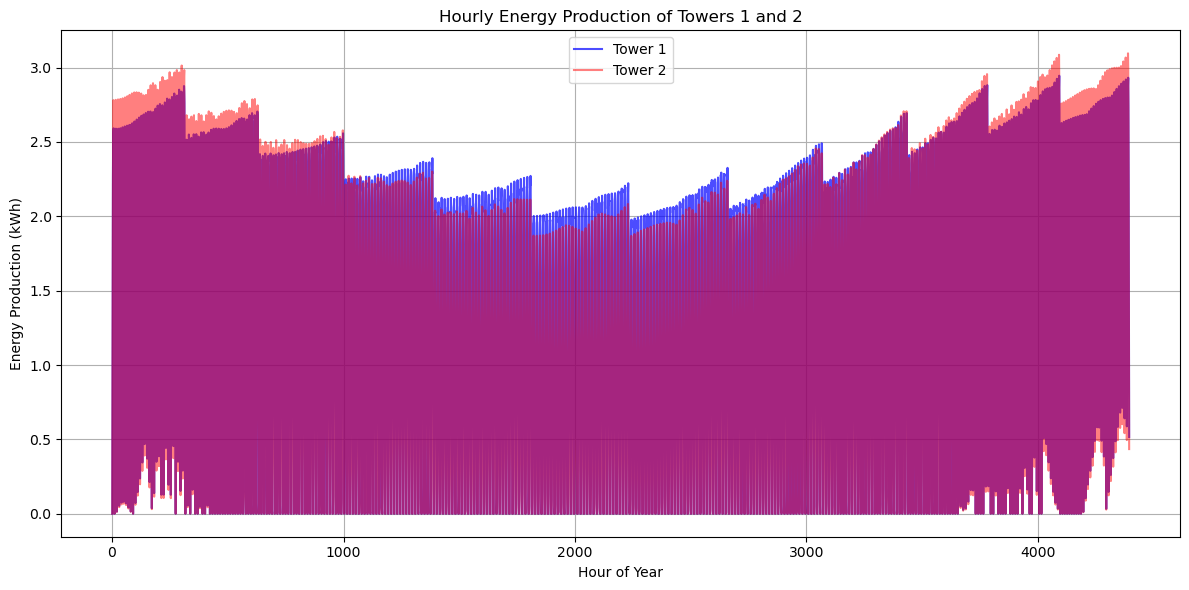

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Example data for one year (hourly)
hours = np.arange(1, len(energy_production_of_tower_1)+1)

# Enable interactive mode
plt.figure(figsize=(12, 6))

# Plot energy production of Tower 1
plt.plot(hours, energy_production_of_tower_1, label="Tower 1",color='b', alpha=0.7)

# Plot energy production of Tower 2
plt.plot(hours, energy_production_of_tower_2, label="Tower 2",color='r', alpha=0.5)

plt.title("Hourly Energy Production of Towers 1 and 2")
plt.xlabel("Hour of Year")
plt.ylabel("Energy Production (kWh)")
plt.legend()
plt.grid(True)

# Enable zoom functionality
plt.tight_layout()
plt.show()

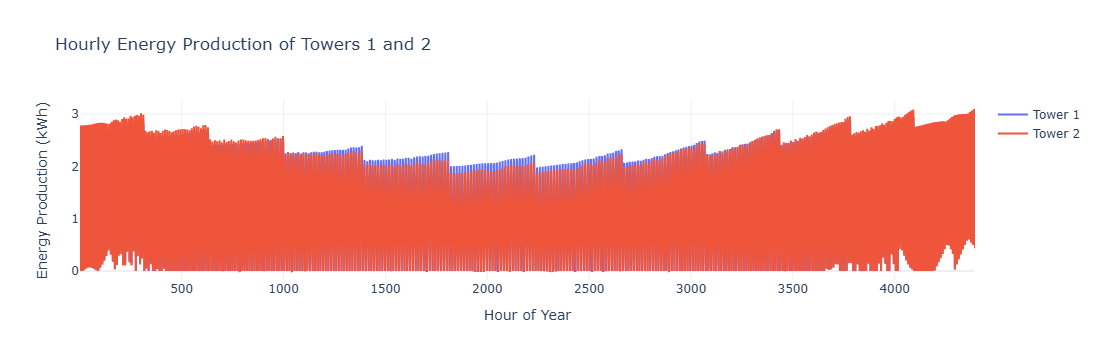

In [ ]:
import plotly.graph_objects as go

# Create the interactive plot
fig = go.Figure()

fig.add_trace(go.Scatter(x=hours, y=energy_production_of_tower_1, mode='lines', name='Tower 1'))
fig.add_trace(go.Scatter(x=hours, y=energy_production_of_tower_2, mode='lines', name='Tower 2'))

fig.update_layout(
    title="Hourly Energy Production of Towers 1 and 2",
    xaxis_title="Hour of Year",
    yaxis_title="Energy Production (kWh)",
    template="plotly_white"
)

fig.show()

In [ ]:
solar_vectors_df_60min['tower_1_energy'] = energy_production_of_tower_1
solar_vectors_df_60min['tower_2_energy'] = energy_production_of_tower_2
solar_vectors_df_60min

,sx,sy,sz,time,tower_1_energy,tower_2_energy
0,0.886974,-0.461814,0.002375,2024-01-01 06:57:00,0.000000,0.000000
1,0.792877,-0.579063,0.189822,2024-01-01 07:57:00,0.888819,0.761564
2,0.644774,-0.679403,0.350254,2024-01-01 08:57:00,1.703006,1.515584
3,0.452749,-0.755997,0.472744,2024-01-01 09:57:00,2.274479,2.139387
4,0.229878,-0.803623,0.548950,2024-01-01 10:57:00,2.557988,2.579325
...,...,...,...,...,...,...
4389,0.194058,-0.809063,0.554759,2024-12-30 12:43:00,2.932115,2.991401
4390,0.420191,-0.766143,0.486277,2024-12-30 13:43:00,2.743467,2.606601
4391,0.617716,-0.693640,0.370527,2024-12-30 14:43:00,2.247951,2.016020
4392,0.773180,-0.596488,0.215394,2024-12-30 15:43:00,1.478449,1.273059


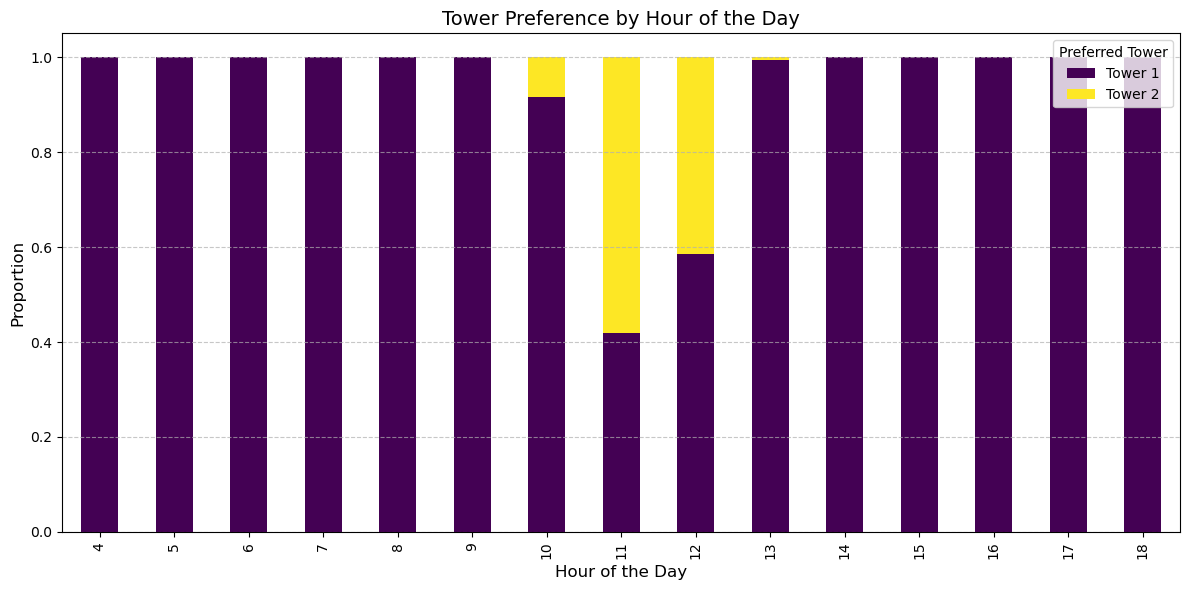

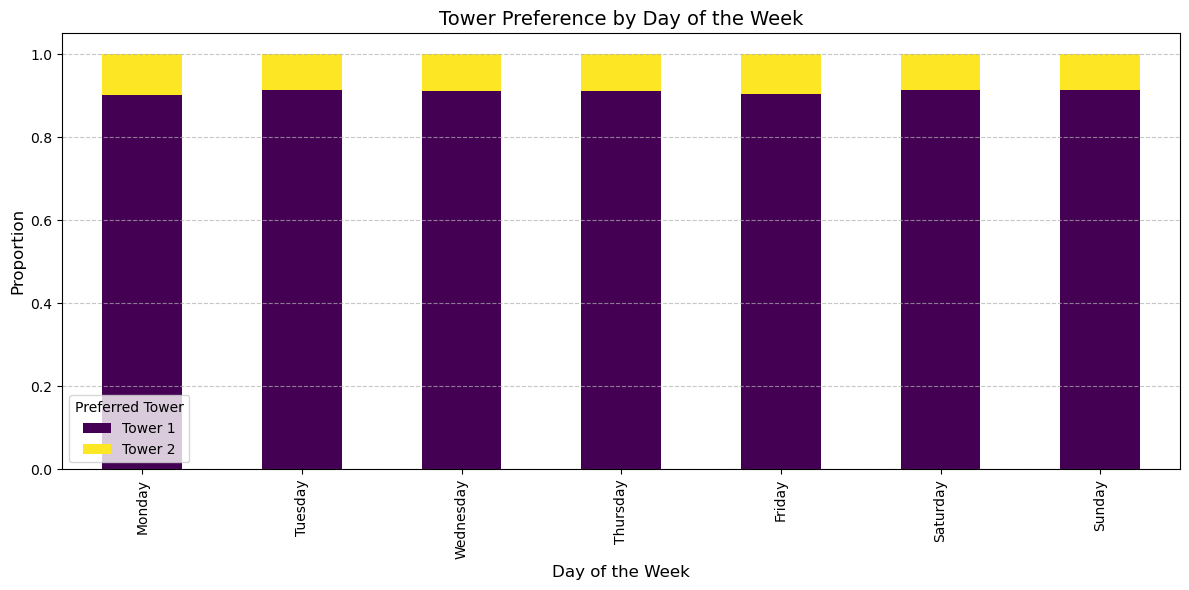

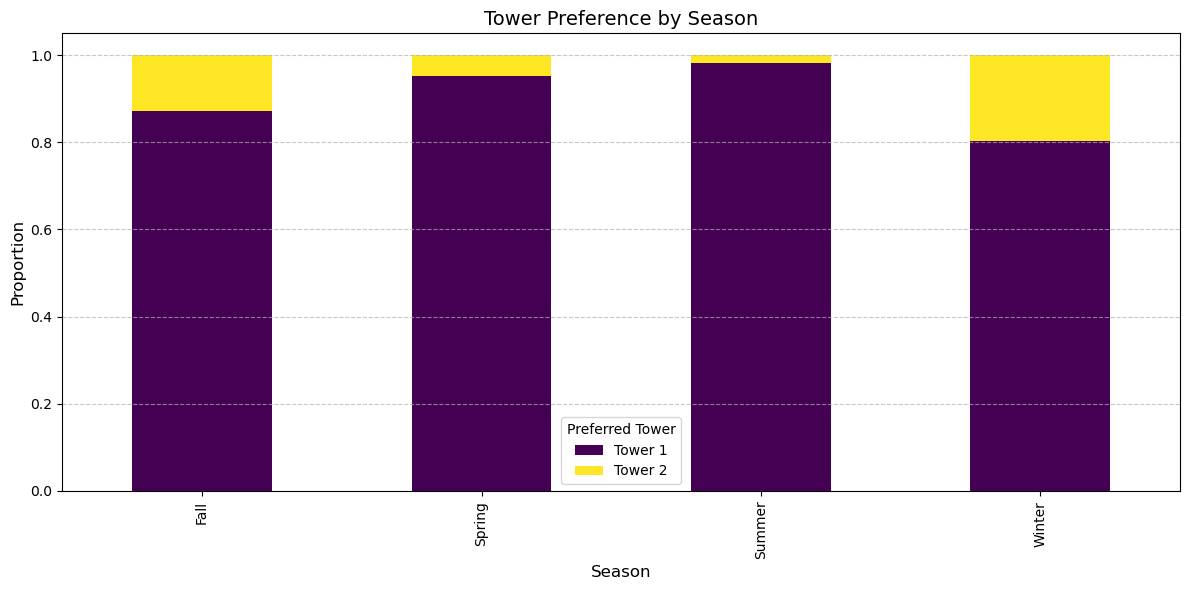

In [ ]:
# Determine the preferred tower
solar_vectors_df_60min["preferred_tower"] = np.where(
    solar_vectors_df_60min["tower_1_energy"] >= solar_vectors_df_60min["tower_2_energy"], "Tower 1", "Tower 2"
)

# Add extra columns for hour, day, and season
solar_vectors_df_60min["hour"       ] = solar_vectors_df_60min["time"].dt.hour
solar_vectors_df_60min["day_of_week"] = solar_vectors_df_60min["time"].dt.dayofweek  # 0=Monday, 6=Sunday
solar_vectors_df_60min["month"      ] = solar_vectors_df_60min["time"].dt.month

# Define seasons
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Fall"

solar_vectors_df_60min["season"] = solar_vectors_df_60min["month"].apply(get_season)

# Plot preferences by hour
hourly_preference = solar_vectors_df_60min.groupby("hour")["preferred_tower"].value_counts(normalize=True).unstack()
hourly_preference.plot(kind="bar", stacked=True, figsize=(12, 6), colormap="viridis")
plt.title("Tower Preference by Hour of the Day", fontsize=14)
plt.xlabel("Hour of the Day", fontsize=12)
plt.ylabel("Proportion", fontsize=12)
plt.legend(title="Preferred Tower")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

# Plot preferences by day of the week
daily_preference = solar_vectors_df_60min.groupby("day_of_week")["preferred_tower"].value_counts(normalize=True).unstack()
daily_preference.index = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
daily_preference.plot(kind="bar", stacked=True, figsize=(12, 6), colormap="viridis")
plt.title("Tower Preference by Day of the Week", fontsize=14)
plt.xlabel("Day of the Week", fontsize=12)
plt.ylabel("Proportion", fontsize=12)
plt.legend(title="Preferred Tower")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

# Plot preferences by season
seasonal_preference = solar_vectors_df_60min.groupby("season")["preferred_tower"].value_counts(normalize=True).unstack()
seasonal_preference.plot(kind="bar", stacked=True, figsize=(12, 6), colormap="viridis")
plt.title("Tower Preference by Season", fontsize=14)
plt.xlabel("Season", fontsize=12)
plt.ylabel("Proportion", fontsize=12)
plt.legend(title="Preferred Tower")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

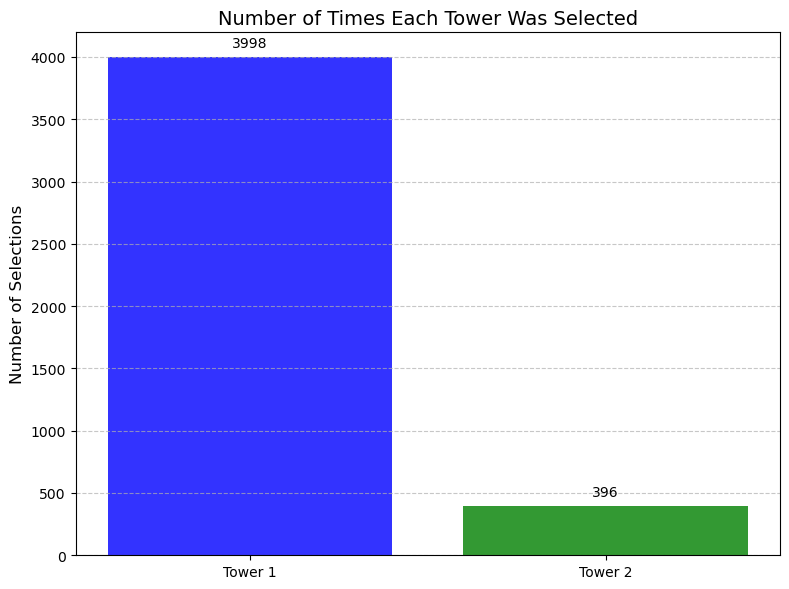

In [ ]:
# Determine the number of times each tower was selected
tower_1_selected = sum(solar_vectors_df_60min["preferred_tower"] == 'Tower 1')
tower_2_selected = sum(solar_vectors_df_60min["preferred_tower"] == 'Tower 2')

# Prepare data for the plot
towers = ["Tower 1", "Tower 2"]
selection_counts = [tower_1_selected, tower_2_selected]

# Create the bar chart
plt.figure(figsize=(8, 6))
plt.bar(towers, selection_counts, color=["blue", "green"], alpha=0.8)

# Add labels and title
plt.title("Number of Times Each Tower Was Selected", fontsize=14)
plt.ylabel("Number of Selections", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Display values on top of the bars
for i, v in enumerate(selection_counts):
    plt.text(i, v + 0.02 * max(selection_counts), f"{v}", ha='center', fontsize=10)

# Show the plot
plt.tight_layout()
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

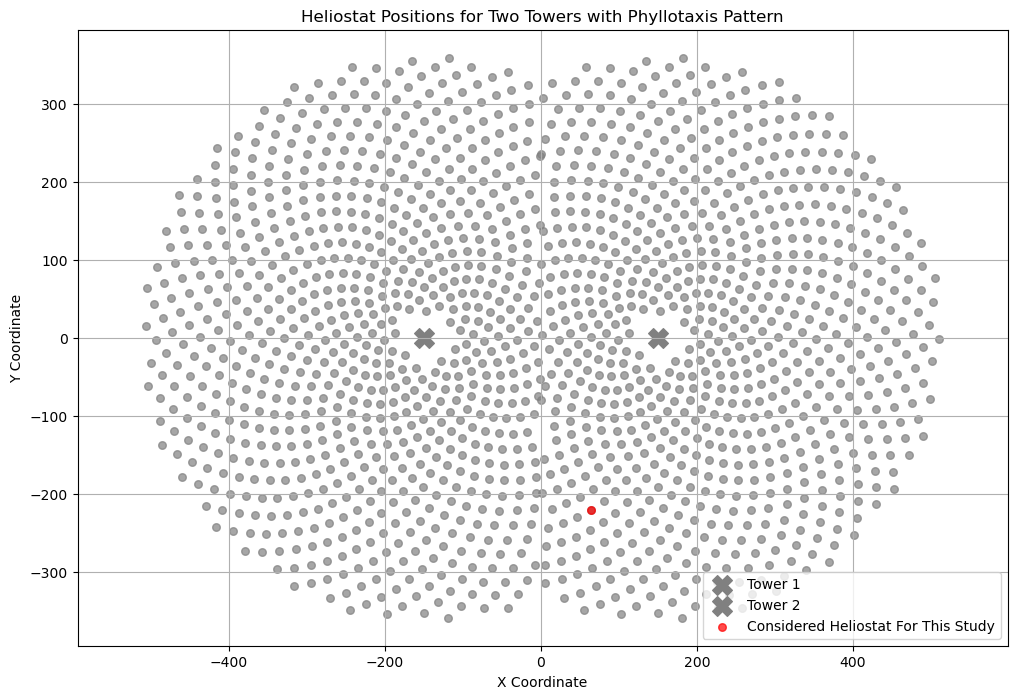

In [ ]:
# Plotting
plt.figure(figsize=(12, 8))

# Plot filtered heliostats for tower 1
plt.scatter(heliostats_tower1[:, 0], heliostats_tower1[:, 1], s=30, color='gray', alpha=0.7)
# Plot filtered heliostats for tower 2
plt.scatter(heliostats_tower2[:, 0], heliostats_tower2[:, 1], s=30, color='gray', alpha=0.7)
# Plot towers
plt.scatter(tower1_position[0], tower1_position[1], s=200, color='gray', marker='X', label='Tower 1')  # Tower 1
plt.scatter(tower2_position[0], tower2_position[1], s=200, color='gray', marker='X', label='Tower 2')  # Tower 2

# Highlight heliostats near the middle of the field
plt.scatter(sample_heliostat['x_h'],
            sample_heliostat['y_h'],
            s=30, color='red', alpha=0.7,
            label='Considered Heliostat For This Study')

# Add title, labels, grid, legend, and aspect ratio adjustment
plt.title('Heliostat Positions for Two Towers with Phyllotaxis Pattern')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.axis('equal')  # Ensure aspect ratio is equal
plt.grid()
plt.legend()
plt.show()

In [ ]:
solar_vectors_df_60min

,sx,sy,sz,time,tower_1_energy,tower_2_energy,preferred_tower,hour,day_of_week,month,season
0,0.886974,-0.461814,0.002375,2024-01-01 06:57:00,0.000000,0.000000,Tower 1,6,0,1,Winter
1,0.792877,-0.579063,0.189822,2024-01-01 07:57:00,0.888819,0.761564,Tower 1,7,0,1,Winter
2,0.644774,-0.679403,0.350254,2024-01-01 08:57:00,1.703006,1.515584,Tower 1,8,0,1,Winter
3,0.452749,-0.755997,0.472744,2024-01-01 09:57:00,2.274479,2.139387,Tower 1,9,0,1,Winter
4,0.229878,-0.803623,0.548950,2024-01-01 10:57:00,2.557988,2.579325,Tower 2,10,0,1,Winter
...,...,...,...,...,...,...,...,...,...,...,...
4389,0.194058,-0.809063,0.554759,2024-12-30 12:43:00,2.932115,2.991401,Tower 2,12,0,12,Winter
4390,0.420191,-0.766143,0.486277,2024-12-30 13:43:00,2.743467,2.606601,Tower 1,13,0,12,Winter
4391,0.617716,-0.693640,0.370527,2024-12-30 14:43:00,2.247951,2.016020,Tower 1,14,0,12,Winter
4392,0.773180,-0.596488,0.215394,2024-12-30 15:43:00,1.478449,1.273059,Tower 1,15,0,12,Winter


In [ ]:
# Initialize new columns for energy consumption
solar_vectors_df_60min['tower_1_energy_consumption'] = 0.0
solar_vectors_df_60min['tower_2_energy_consumption'] = 0.0

# Loop through each row of the DataFrame
for i in range(len(solar_vectors_df_60min) - 1):
    # Current and next indices
    current_idx = i
    next_idx = i + 1

    # Get current and next tower numbers
    current_tower_number_1 = 1  # Assuming tower number is constant (Tower 1)
    current_tower_number_2 = 2  # Assuming tower number is constant (Tower 2)

    # Calculate energy consumption for Tower 1
    solar_vectors_df_60min.loc[current_idx, 'tower_1_energy_consumption'] = energy_consumption_at_each_time_step(
        current_idx, next_idx, current_tower_number_1, current_tower_number_1, solar_vectors_df_60min
    )

    # Calculate energy consumption for Tower 2
    solar_vectors_df_60min.loc[current_idx, 'tower_2_energy_consumption'] = energy_consumption_at_each_time_step(
        current_idx, next_idx, current_tower_number_2, current_tower_number_2, solar_vectors_df_60min
    )

# For the last row, set energy consumption to NaN or 0 as there's no "next" row to compare
solar_vectors_df_60min.loc[len(solar_vectors_df_60min) - 1, ['tower_1_energy_consumption', 'tower_2_energy_consumption']] = 0.0

# View updated DataFrame
solar_vectors_df_60min

,sx,sy,sz,time,tower_1_energy,tower_2_energy,preferred_tower,hour,day_of_week,month,season,tower_1_energy_consumption,tower_2_energy_consumption
0,0.886974,-0.461814,0.002375,2024-01-01 06:57:00,0.000000,0.000000,Tower 1,6,0,1,Winter,0.000516,0.000731
1,0.792877,-0.579063,0.189822,2024-01-01 07:57:00,0.888819,0.761564,Tower 1,7,0,1,Winter,0.000584,0.000806
2,0.644774,-0.679403,0.350254,2024-01-01 08:57:00,1.703006,1.515584,Tower 1,8,0,1,Winter,0.000654,0.000853
3,0.452749,-0.755997,0.472744,2024-01-01 09:57:00,2.274479,2.139387,Tower 1,9,0,1,Winter,0.000724,0.000527
4,0.229878,-0.803623,0.548950,2024-01-01 10:57:00,2.557988,2.579325,Tower 2,10,0,1,Winter,0.000732,0.000806
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4389,0.194058,-0.809063,0.554759,2024-12-30 12:43:00,2.932115,2.991401,Tower 2,12,0,12,Winter,0.000734,0.000465
4390,0.420191,-0.766143,0.486277,2024-12-30 13:43:00,2.743467,2.606601,Tower 1,13,0,12,Winter,0.000664,0.000857
4391,0.617716,-0.693640,0.370527,2024-12-30 14:43:00,2.247951,2.016020,Tower 1,14,0,12,Winter,0.000595,0.000815
4392,0.773180,-0.596488,0.215394,2024-12-30 15:43:00,1.478449,1.273059,Tower 1,15,0,12,Winter,0.000527,0.000744


In [ ]:
solar_vectors_df_60min['real_energy_production_tower_1'] = solar_vectors_df_60min['tower_1_energy'] - solar_vectors_df_60min['tower_1_energy_consumption']
solar_vectors_df_60min['real_energy_production_tower_2'] = solar_vectors_df_60min['tower_2_energy'] - solar_vectors_df_60min['tower_2_energy_consumption']
solar_vectors_df_60min[['real_energy_production_tower_1', 'real_energy_production_tower_2']]

,real_energy_production_tower_1,real_energy_production_tower_2
0,-0.000516,-0.000731
1,0.888234,0.760758
2,1.702352,1.514731
3,2.273756,2.138861
4,2.557256,2.578519
...,...,...
4389,2.931381,2.990936
4390,2.742802,2.605744
4391,2.247356,2.015205
4392,1.477922,1.272315


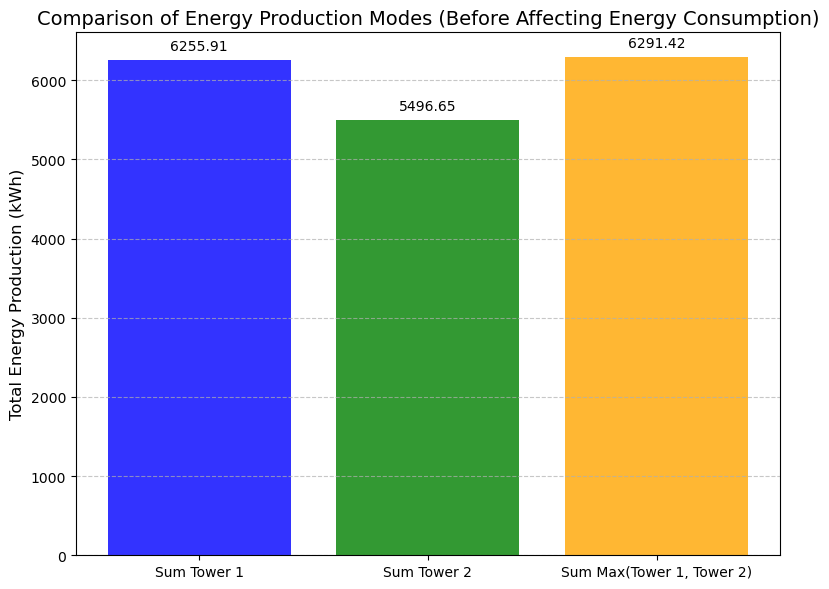

In [ ]:
# Calculate the sums for the three modes
sum_tower_1 = np.sum(energy_production_of_tower_1)
sum_tower_2 = np.sum(energy_production_of_tower_2)
sum_max_towers = np.sum([max(t1, t2) for t1, t2 in zip(energy_production_of_tower_1, energy_production_of_tower_2)])

tower_1_selected = sum(solar_vectors_df_60min["preferred_tower"] == 'Tower 1')
tower_2_selected = sum(solar_vectors_df_60min["preferred_tower"] == 'Tower 2')

# Prepare data for the bar chart
modes = ["Sum Tower 1", "Sum Tower 2", "Sum Max(Tower 1, Tower 2)"]
values = [sum_tower_1, sum_tower_2, sum_max_towers]

# Create the bar chart
plt.figure(figsize=(8, 6))
plt.bar(modes, values, color=["blue", "green", "orange"], alpha=0.8)

# Add labels and title
plt.title("Comparison of Energy Production Modes (Before Affecting Energy Consumption)", fontsize=14)
plt.ylabel("Total Energy Production (kWh)", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Display values on top of the bars
for i, v in enumerate(values):
    plt.text(i, v + 0.02 * max(values), f"{v:.2f}", ha='center', fontsize=10)

# Show the plot
plt.tight_layout()
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

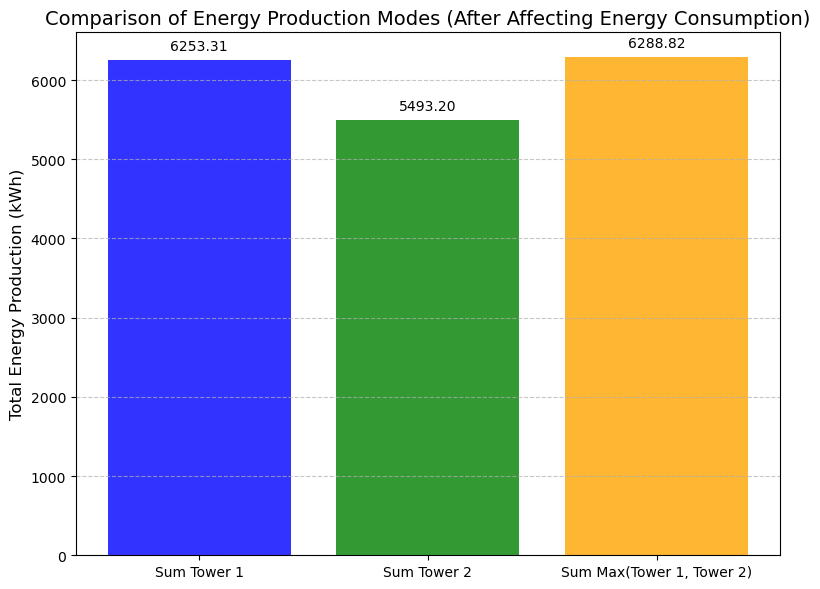

In [ ]:
# Calculate the sums for the three modes
sum_tower_1 = np.sum(solar_vectors_df_60min['real_energy_production_tower_1'])
sum_tower_2 = np.sum(solar_vectors_df_60min['real_energy_production_tower_2'])

sum_max_towers = np.sum(np.maximum(solar_vectors_df_60min['real_energy_production_tower_1'], solar_vectors_df_60min['real_energy_production_tower_2']))

# Prepare data for the bar chart
modes = ["Sum Tower 1", "Sum Tower 2", "Sum Max(Tower 1, Tower 2)"]
values = [sum_tower_1, sum_tower_2, sum_max_towers]

# Create the bar chart
plt.figure(figsize=(8, 6))
plt.bar(modes, values, color=["blue", "green", "orange"], alpha=0.8)

# Add labels and title
plt.title("Comparison of Energy Production Modes (After Affecting Energy Consumption)", fontsize=14)
plt.ylabel("Total Energy Production (kWh)", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Display values on top of the bars
for i, v in enumerate(values):
    plt.text(i, v + 0.02 * max(values), f"{v:.2f}", ha='center', fontsize=10)

# Show the plot
plt.tight_layout()
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

# Plot 2: Fake Situation Which We Have Clouds over Tower 1 or 2 at Random

In [ ]:
solar_vectors_df_custon_min = solar_vectors_df[::180].reset_index(drop=True)
solar_vectors_df_custon_min

,sx,sy,sz,time
0,0.886974,-0.461814,0.002375,2024-01-01 06:57:00
1,0.452749,-0.755997,0.472744,2024-01-01 09:57:00
2,0.246624,-0.801173,0.545251,2024-01-01 12:57:00
3,0.801713,-0.570767,0.177433,2024-01-01 15:57:00
4,0.637815,-0.682220,0.357445,2024-01-02 09:00:00
...,...,...,...,...
1460,0.403641,-0.771238,0.492204,2024-12-29 13:38:00
1461,0.869743,-0.491416,0.045363,2024-12-29 16:38:00
1462,0.498584,-0.742260,0.447732,2024-12-30 09:43:00
1463,0.194058,-0.809063,0.554759,2024-12-30 12:43:00


In [ ]:
import random

# Define cloud factor (percentage of radiance reduction due to clouds)
cloud_factor = 0.3  # 30% reduction in radiance

# Initialize energy production lists
energy_production_of_tower_1 = []
energy_production_of_tower_2 = []

start_time = datetime.now()

for i, solar_vector in solar_vectors_df_custon_min.iterrows():
    if i % 100 == 0:
        print(i)
        print('Time passed since starting:', datetime.now() - start_time)

    # Calculate heliostat normal vectors
    heliostat_normal_vector_tower1 = calculate_heliostat_normal(solar_vector.values, r1_normalized.values)
    heliostat_normal_vector_tower2 = calculate_heliostat_normal(solar_vector.values, r2_normalized.values)

    # Calculate solar elevation angles
    sea_1 = solar_elevation_angle(solar_vector['time'], latitude)
    sea_2 = solar_elevation_angle(solar_vector['time'], latitude)

    # Calculate initial radiance
    radiance_1 = calculate_irradiance(sea_1)
    radiance_2 = calculate_irradiance(sea_2)

    # Randomly simulate cloud cover
    cloud_decision = random.choice(['none', 'tower1', 'tower2', 'both'])

    if cloud_decision == 'tower1' or cloud_decision == 'both':
        radiance_1 *= cloud_factor  # Reduce radiance for Tower 1
    if cloud_decision == 'tower2' or cloud_decision == 'both':
        radiance_2 *= cloud_factor  # Reduce radiance for Tower 2

    # Calculate total efficiencies
    total_efficiency_1 = caclculate_total_efficiency(
        heliostat_normal_vector_tower1, solar_vector[['sx', 'sy', 'sz']], tower1_position)
    total_efficiency_2 = caclculate_total_efficiency(
        heliostat_normal_vector_tower2, solar_vector[['sx', 'sy', 'sz']], tower2_position)

    # Calculate energy production
    energy_production_1 = calculate_energy_production(radiance_1, total_efficiency_1)
    energy_production_2 = calculate_energy_production(radiance_2, total_efficiency_2)

    # Append results to lists
    energy_production_of_tower_1.append(energy_production_1)
    energy_production_of_tower_2.append(energy_production_2)

0
Time passed since starting: 0:00:00.000999
100
Time passed since starting: 0:00:51.468104
200
Time passed since starting: 0:01:41.996482
300
Time passed since starting: 0:02:32.894155
400
Time passed since starting: 0:03:23.958558
500
Time passed since starting: 0:04:14.818221
600
Time passed since starting: 0:05:05.563347
700
Time passed since starting: 0:05:55.701994
800
Time passed since starting: 0:06:45.851990
900
Time passed since starting: 0:07:36.779535
1000
Time passed since starting: 0:08:27.273507
1100
Time passed since starting: 0:09:17.775287
1200
Time passed since starting: 0:10:08.509009
1300
Time passed since starting: 0:10:58.823629
1400
Time passed since starting: 0:11:49.070280


In [ ]:
import pickle

with open('energy_production_of_tower_1_v2.pkl', 'wb') as f:
  pickle.dump(energy_production_of_tower_1, f)

with open('energy_production_of_tower_2_v2.pkl', 'wb') as f:
  pickle.dump(energy_production_of_tower_2, f)

In [ ]:
with open('energy_production_of_tower_1_v2.pkl', 'rb') as f:
  energy_production_of_tower_1 = pickle.load(f)

with open('energy_production_of_tower_2_v2.pkl', 'rb') as f:
  energy_production_of_tower_2 = pickle.load(f)

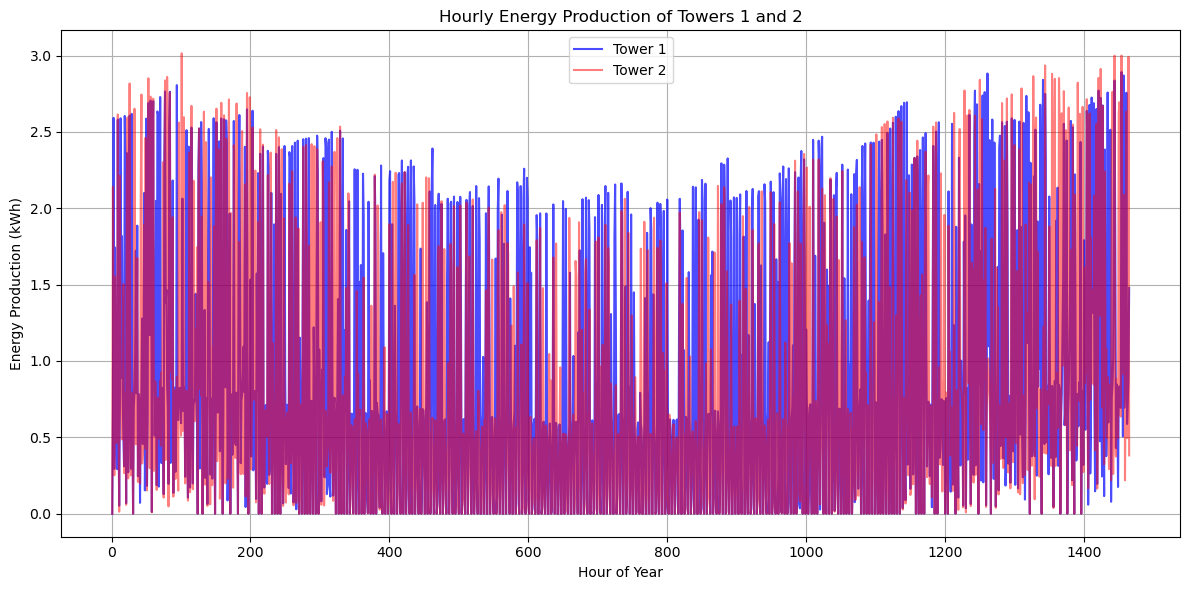

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Example data for one year (hourly)
hours = np.arange(1, len(energy_production_of_tower_1)+1)

# Enable interactive mode
plt.figure(figsize=(12, 6))

# Plot energy production of Tower 1
plt.plot(hours, energy_production_of_tower_1, label="Tower 1",color='b', alpha=0.7)

# Plot energy production of Tower 2
plt.plot(hours, energy_production_of_tower_2, label="Tower 2",color='r', alpha=0.5)

plt.title("Hourly Energy Production of Towers 1 and 2")
plt.xlabel("Hour of Year")
plt.ylabel("Energy Production (kWh)")
plt.legend()
plt.grid(True)

# Enable zoom functionality
plt.tight_layout()
plt.show()

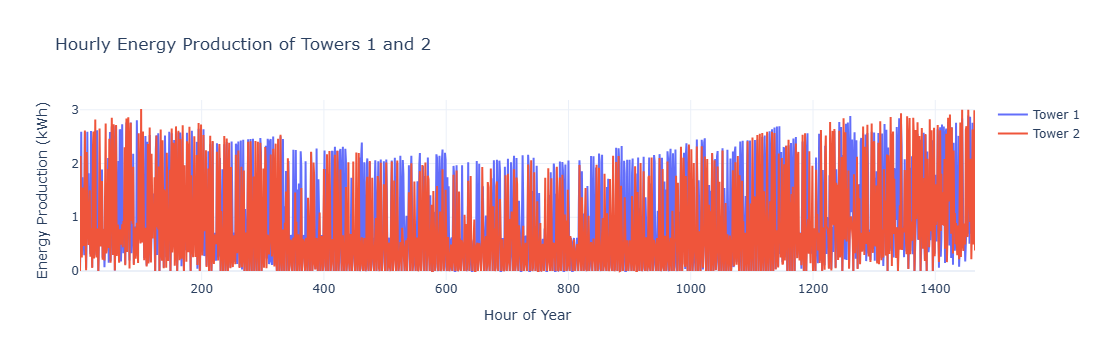

In [ ]:
import plotly.graph_objects as go

# Create the interactive plot
fig = go.Figure()

fig.add_trace(go.Scatter(x=hours, y=energy_production_of_tower_1, mode='lines', name='Tower 1'))
fig.add_trace(go.Scatter(x=hours, y=energy_production_of_tower_2, mode='lines', name='Tower 2'))

fig.update_layout(
    title="Hourly Energy Production of Towers 1 and 2",
    xaxis_title="Hour of Year",
    yaxis_title="Energy Production (kWh)",
    template="plotly_white"
)

fig.show()

In [ ]:
solar_vectors_df_custon_min['tower_1_energy'] = energy_production_of_tower_1
solar_vectors_df_custon_min['tower_2_energy'] = energy_production_of_tower_2
solar_vectors_df_custon_min

,sx,sy,sz,time,tower_1_energy,tower_2_energy
0,0.886974,-0.461814,0.002375,2024-01-01 06:57:00,0.000000,0.000000
1,0.452749,-0.755997,0.472744,2024-01-01 09:57:00,0.682344,2.139387
2,0.246624,-0.801173,0.545251,2024-01-01 12:57:00,2.591793,0.779810
3,0.801713,-0.570767,0.177433,2024-01-01 15:57:00,0.293801,0.251194
4,0.637815,-0.682220,0.357445,2024-01-02 09:00:00,1.742956,1.553687
...,...,...,...,...,...,...
1460,0.403641,-0.771238,0.492204,2024-12-29 13:38:00,2.756298,2.632467
1461,0.869743,-0.491416,0.045363,2024-12-29 16:38:00,0.587493,0.495382
1462,0.498584,-0.742260,0.447732,2024-12-30 09:43:00,0.745393,0.691773
1463,0.194058,-0.809063,0.554759,2024-12-30 12:43:00,0.879635,2.991401


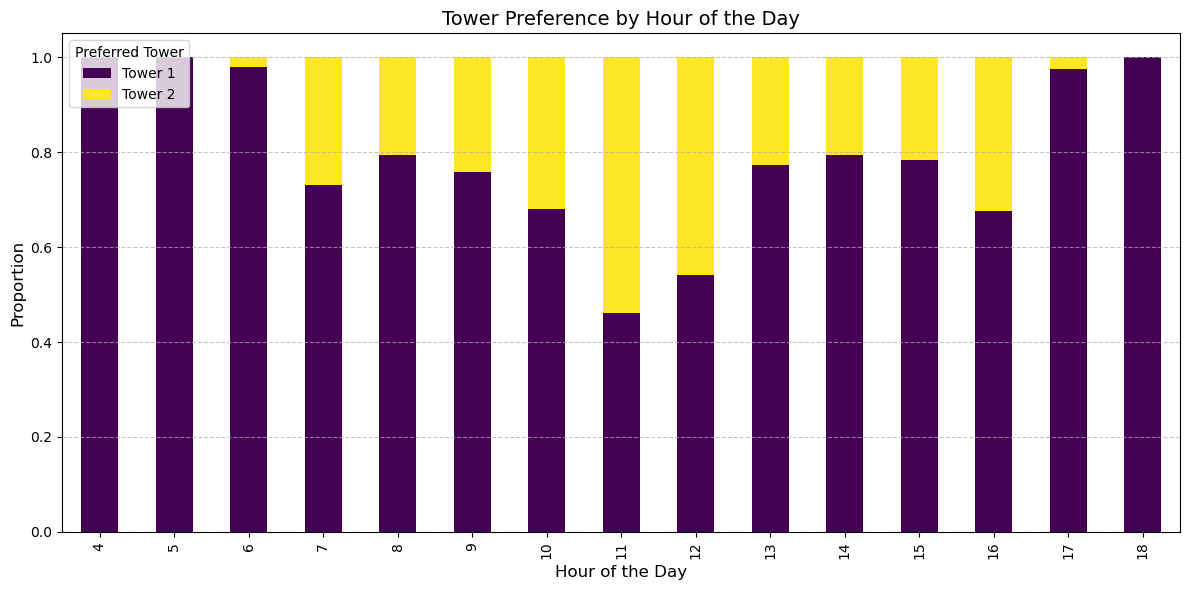

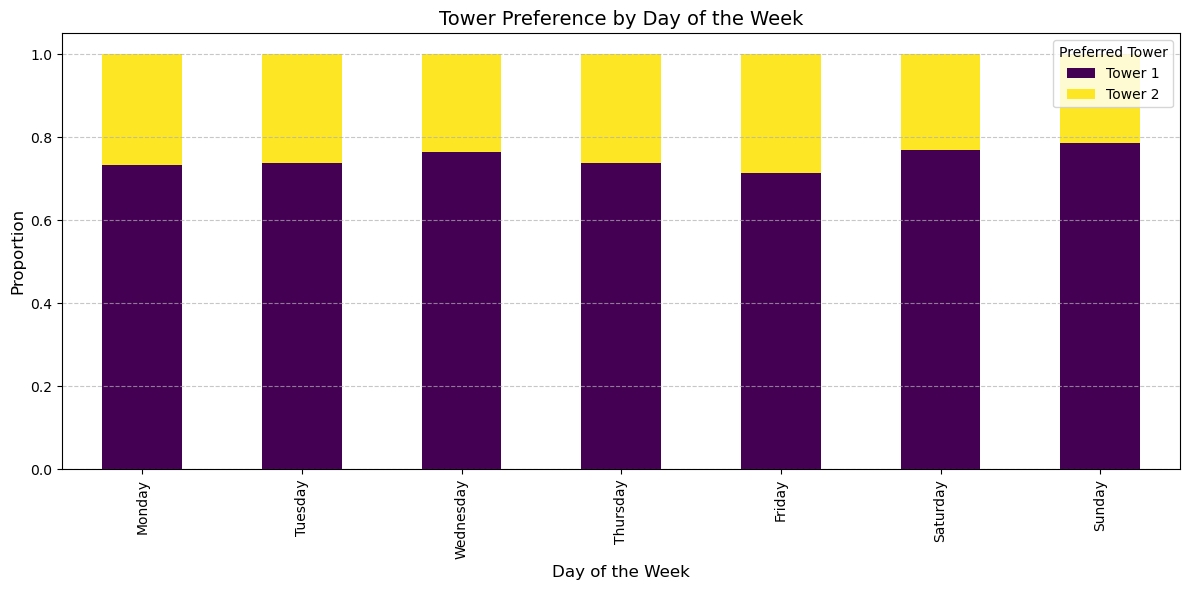

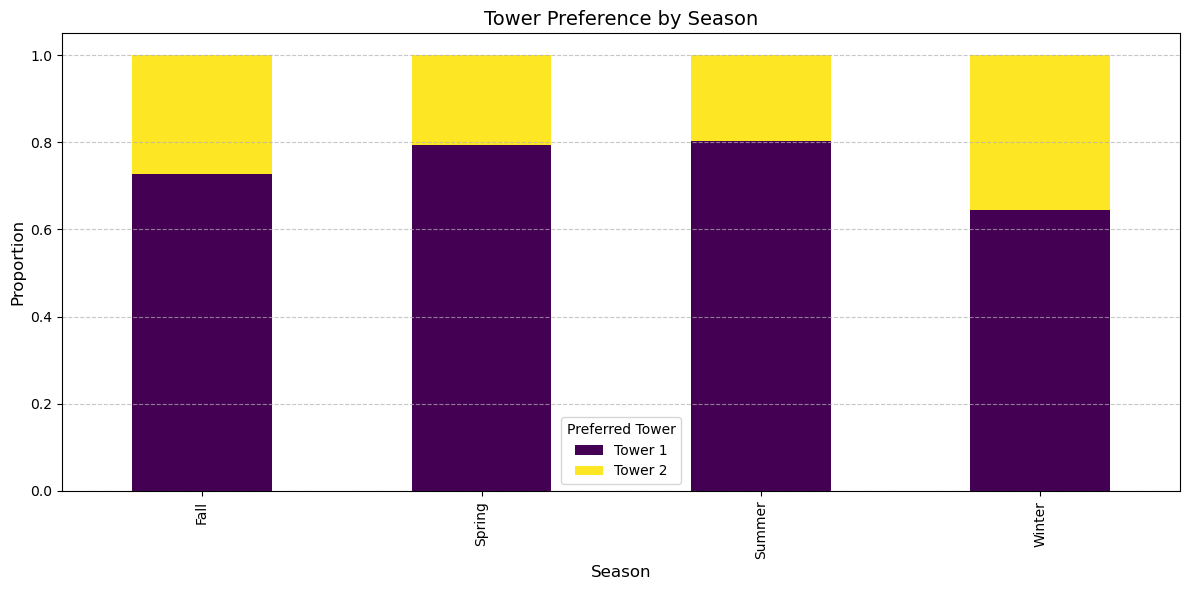

In [ ]:
# Determine the preferred tower
solar_vectors_df_custon_min["preferred_tower"] = np.where(
    solar_vectors_df_custon_min["tower_1_energy"] >= solar_vectors_df_custon_min["tower_2_energy"], "Tower 1", "Tower 2"
)

# Add extra columns for hour, day, and season
solar_vectors_df_custon_min["hour"       ] = solar_vectors_df_custon_min["time"].dt.hour
solar_vectors_df_custon_min["day_of_week"] = solar_vectors_df_custon_min["time"].dt.dayofweek  # 0=Monday, 6=Sunday
solar_vectors_df_custon_min["month"      ] = solar_vectors_df_custon_min["time"].dt.month

# Define seasons
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Fall"

solar_vectors_df_custon_min["season"] = solar_vectors_df_custon_min["month"].apply(get_season)

# Plot preferences by hour
hourly_preference = solar_vectors_df_custon_min.groupby("hour")["preferred_tower"].value_counts(normalize=True).unstack()
hourly_preference.plot(kind="bar", stacked=True, figsize=(12, 6), colormap="viridis")
plt.title("Tower Preference by Hour of the Day", fontsize=14)
plt.xlabel("Hour of the Day", fontsize=12)
plt.ylabel("Proportion", fontsize=12)
plt.legend(title="Preferred Tower")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

# Plot preferences by day of the week
daily_preference = solar_vectors_df_custon_min.groupby("day_of_week")["preferred_tower"].value_counts(normalize=True).unstack()
daily_preference.index = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
daily_preference.plot(kind="bar", stacked=True, figsize=(12, 6), colormap="viridis")
plt.title("Tower Preference by Day of the Week", fontsize=14)
plt.xlabel("Day of the Week", fontsize=12)
plt.ylabel("Proportion", fontsize=12)
plt.legend(title="Preferred Tower")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

# Plot preferences by season
seasonal_preference = solar_vectors_df_custon_min.groupby("season")["preferred_tower"].value_counts(normalize=True).unstack()
seasonal_preference.plot(kind="bar", stacked=True, figsize=(12, 6), colormap="viridis")
plt.title("Tower Preference by Season", fontsize=14)
plt.xlabel("Season", fontsize=12)
plt.ylabel("Proportion", fontsize=12)
plt.legend(title="Preferred Tower")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

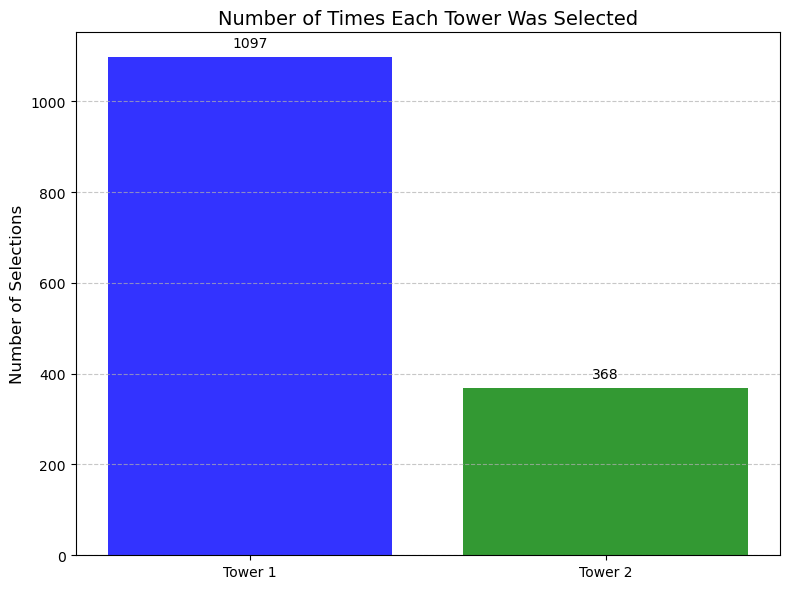

In [ ]:
# Determine the number of times each tower was selected
tower_1_selected = sum(solar_vectors_df_custon_min["preferred_tower"] == 'Tower 1')
tower_2_selected = sum(solar_vectors_df_custon_min["preferred_tower"] == 'Tower 2')

# Prepare data for the plot
towers = ["Tower 1", "Tower 2"]
selection_counts = [tower_1_selected, tower_2_selected]

# Create the bar chart
plt.figure(figsize=(8, 6))
plt.bar(towers, selection_counts, color=["blue", "green"], alpha=0.8)

# Add labels and title
plt.title("Number of Times Each Tower Was Selected", fontsize=14)
plt.ylabel("Number of Selections", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Display values on top of the bars
for i, v in enumerate(selection_counts):
    plt.text(i, v + 0.02 * max(selection_counts), f"{v}", ha='center', fontsize=10)

# Show the plot
plt.tight_layout()
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

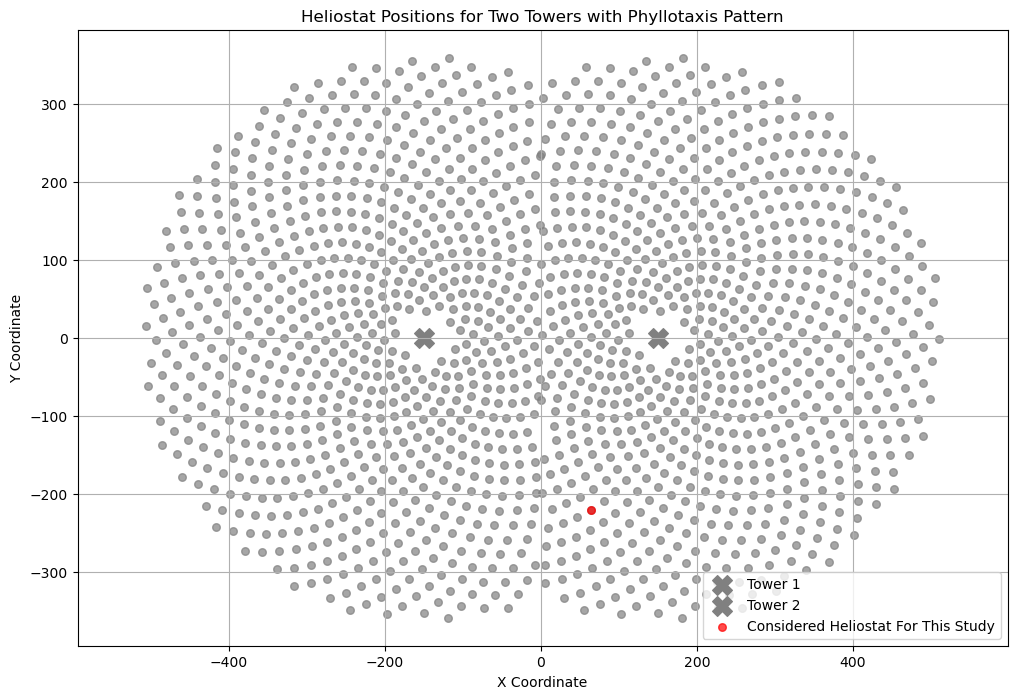

In [ ]:
# Plotting
plt.figure(figsize=(12, 8))

# Plot filtered heliostats for tower 1
plt.scatter(heliostats_tower1[:, 0], heliostats_tower1[:, 1], s=30, color='gray', alpha=0.7)
# Plot filtered heliostats for tower 2
plt.scatter(heliostats_tower2[:, 0], heliostats_tower2[:, 1], s=30, color='gray', alpha=0.7)
# Plot towers
plt.scatter(tower1_position[0], tower1_position[1], s=200, color='gray', marker='X', label='Tower 1')  # Tower 1
plt.scatter(tower2_position[0], tower2_position[1], s=200, color='gray', marker='X', label='Tower 2')  # Tower 2

# Highlight heliostats near the middle of the field
plt.scatter(sample_heliostat['x_h'],
            sample_heliostat['y_h'],
            s=30, color='red', alpha=0.7,
            label='Considered Heliostat For This Study')

# Add title, labels, grid, legend, and aspect ratio adjustment
plt.title('Heliostat Positions for Two Towers with Phyllotaxis Pattern')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.axis('equal')  # Ensure aspect ratio is equal
plt.grid()
plt.legend()
plt.show()

In [ ]:
solar_vectors_df_custon_min

,sx,sy,sz,time,tower_1_energy,tower_2_energy,preferred_tower,hour,day_of_week,month,season
0,0.886974,-0.461814,0.002375,2024-01-01 06:57:00,0.000000,0.000000,Tower 1,6,0,1,Winter
1,0.452749,-0.755997,0.472744,2024-01-01 09:57:00,0.682344,2.139387,Tower 2,9,0,1,Winter
2,0.246624,-0.801173,0.545251,2024-01-01 12:57:00,2.591793,0.779810,Tower 1,12,0,1,Winter
3,0.801713,-0.570767,0.177433,2024-01-01 15:57:00,0.293801,0.251194,Tower 1,15,0,1,Winter
4,0.637815,-0.682220,0.357445,2024-01-02 09:00:00,1.742956,1.553687,Tower 1,9,1,1,Winter
...,...,...,...,...,...,...,...,...,...,...,...
1460,0.403641,-0.771238,0.492204,2024-12-29 13:38:00,2.756298,2.632467,Tower 1,13,6,12,Winter
1461,0.869743,-0.491416,0.045363,2024-12-29 16:38:00,0.587493,0.495382,Tower 1,16,6,12,Winter
1462,0.498584,-0.742260,0.447732,2024-12-30 09:43:00,0.745393,0.691773,Tower 1,9,0,12,Winter
1463,0.194058,-0.809063,0.554759,2024-12-30 12:43:00,0.879635,2.991401,Tower 2,12,0,12,Winter


In [ ]:
# Initialize new columns for energy consumption
solar_vectors_df_custon_min['tower_1_energy_consumption'] = 0.0
solar_vectors_df_custon_min['tower_2_energy_consumption'] = 0.0

# Loop through each row of the DataFrame
for i in range(len(solar_vectors_df_custon_min) - 1):
    # Current and next indices
    current_idx = i
    next_idx = i + 1

    # Get current and next tower numbers
    current_tower_number_1 = 1  # Assuming tower number is constant (Tower 1)
    current_tower_number_2 = 2  # Assuming tower number is constant (Tower 2)

    # Calculate energy consumption for Tower 1
    solar_vectors_df_custon_min.loc[current_idx, 'tower_1_energy_consumption'] = energy_consumption_at_each_time_step(
        current_idx, next_idx, current_tower_number_1, current_tower_number_1, solar_vectors_df_custon_min
    )

    # Calculate energy consumption for Tower 2
    solar_vectors_df_custon_min.loc[current_idx, 'tower_2_energy_consumption'] = energy_consumption_at_each_time_step(
        current_idx, next_idx, current_tower_number_2, current_tower_number_2, solar_vectors_df_custon_min
    )

# For the last row, set energy consumption to NaN or 0 as there's no "next" row to compare
solar_vectors_df_custon_min.loc[len(solar_vectors_df_custon_min) - 1, ['tower_1_energy_consumption', 'tower_2_energy_consumption']] = 0.0

# View updated DataFrame
solar_vectors_df_custon_min

,sx,sy,sz,time,tower_1_energy,tower_2_energy,preferred_tower,hour,day_of_week,month,season,tower_1_energy_consumption,tower_2_energy_consumption
0,0.886974,-0.461814,0.002375,2024-01-01 06:57:00,0.000000,0.000000,Tower 1,6,0,1,Winter,0.001754,0.002391
1,0.452749,-0.755997,0.472744,2024-01-01 09:57:00,0.682344,2.139387,Tower 2,9,0,1,Winter,0.000669,0.000526
2,0.246624,-0.801173,0.545251,2024-01-01 12:57:00,2.591793,0.779810,Tower 1,12,0,1,Winter,0.001948,0.002242
3,0.801713,-0.570767,0.177433,2024-01-01 15:57:00,0.293801,0.251194,Tower 1,15,0,1,Winter,0.000648,0.000897
4,0.637815,-0.682220,0.357445,2024-01-02 09:00:00,1.742956,1.553687,Tower 1,9,1,1,Winter,0.002050,0.001352
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1460,0.403641,-0.771238,0.492204,2024-12-29 13:38:00,2.756298,2.632467,Tower 1,13,6,12,Winter,0.001801,0.002427
1461,0.869743,-0.491416,0.045363,2024-12-29 16:38:00,0.587493,0.495382,Tower 1,16,6,12,Winter,0.001487,0.002035
1462,0.498584,-0.742260,0.447732,2024-12-30 09:43:00,0.745393,0.691773,Tower 1,9,0,12,Winter,0.000992,0.000721
1463,0.194058,-0.809063,0.554759,2024-12-30 12:43:00,0.879635,2.991401,Tower 2,12,0,12,Winter,0.001993,0.002068


In [ ]:
solar_vectors_df_custon_min['real_energy_production_tower_1'] = solar_vectors_df_custon_min['tower_1_energy'] - solar_vectors_df_custon_min['tower_1_energy_consumption']
solar_vectors_df_custon_min['real_energy_production_tower_2'] = solar_vectors_df_custon_min['tower_2_energy'] - solar_vectors_df_custon_min['tower_2_energy_consumption']
solar_vectors_df_custon_min[['real_energy_production_tower_1', 'real_energy_production_tower_2']]

,real_energy_production_tower_1,real_energy_production_tower_2
0,-0.001754,-0.002391
1,0.681675,2.138861
2,2.589845,0.777567
3,0.293153,0.250298
4,1.740907,1.552335
...,...,...
1460,2.754498,2.630041
1461,0.586006,0.493347
1462,0.744402,0.691052
1463,0.877641,2.989333


In [ ]:
print(solar_vectors_df_custon_min.columns)

Index(['sx', 'sy', 'sz', 'time', 'tower_1_energy', 'tower_2_energy',
       'preferred_tower', 'hour', 'day_of_week', 'month', 'season',
       'tower_1_energy_consumption', 'tower_2_energy_consumption',
       'real_energy_production_tower_1', 'real_energy_production_tower_2'],
      dtype='object')


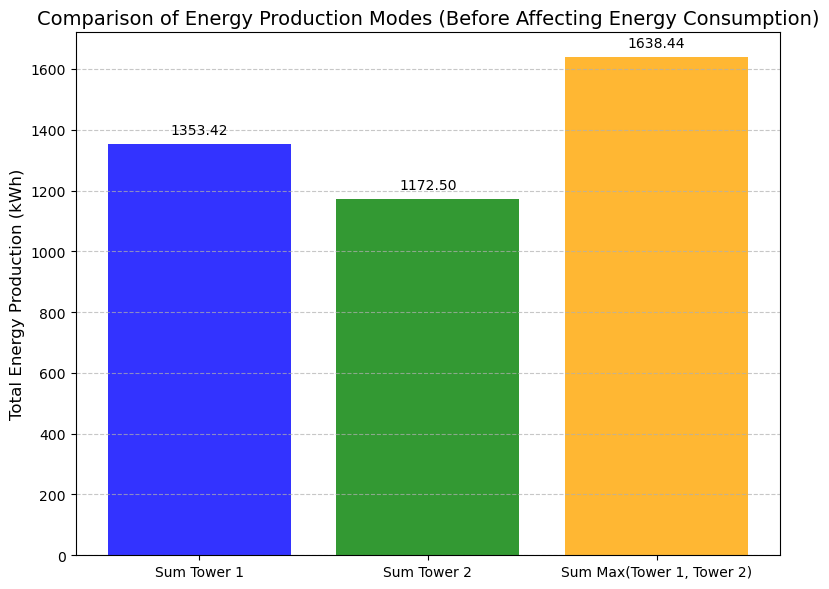

In [ ]:
# Calculate the sums for the three modes
sum_tower_1 = np.sum(energy_production_of_tower_1)
sum_tower_2 = np.sum(energy_production_of_tower_2)
sum_max_towers = np.sum([max(t1, t2) for t1, t2 in zip(energy_production_of_tower_1, energy_production_of_tower_2)])

# Prepare data for the bar chart
modes = ["Sum Tower 1", "Sum Tower 2", "Sum Max(Tower 1, Tower 2)"]
values = [sum_tower_1, sum_tower_2, sum_max_towers]

# Create the bar chart
plt.figure(figsize=(8, 6))
plt.bar(modes, values, color=["blue", "green", "orange"], alpha=0.8)

# Add labels and title
plt.title("Comparison of Energy Production Modes (Before Affecting Energy Consumption)", fontsize=14)
plt.ylabel("Total Energy Production (kWh)", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Display values on top of the bars
for i, v in enumerate(values):
    plt.text(i, v + 0.02 * max(values), f"{v:.2f}", ha='center', fontsize=10)

# Show the plot
plt.tight_layout()
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

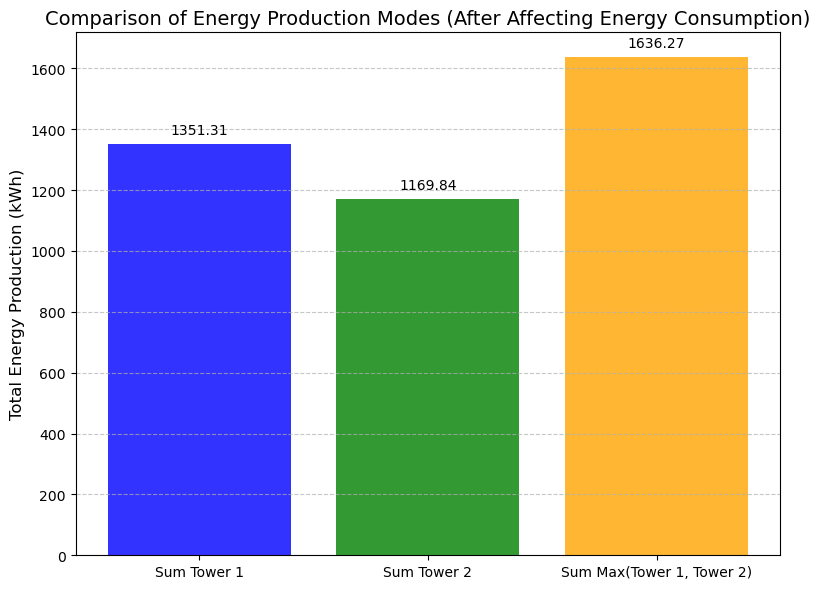

In [ ]:
# Calculate the sums for the three modes
sum_tower_1 = np.sum(solar_vectors_df_custon_min['real_energy_production_tower_1'])
sum_tower_2 = np.sum(solar_vectors_df_custon_min['real_energy_production_tower_2'])

sum_max_towers = np.sum(np.maximum(solar_vectors_df_custon_min['real_energy_production_tower_1'], solar_vectors_df_custon_min['real_energy_production_tower_2']))

# Prepare data for the bar chart
modes = ["Sum Tower 1", "Sum Tower 2", "Sum Max(Tower 1, Tower 2)"]
values = [sum_tower_1, sum_tower_2, sum_max_towers]

# Create the bar chart
plt.figure(figsize=(8, 6))
plt.bar(modes, values, color=["blue", "green", "orange"], alpha=0.8)

# Add labels and title
plt.title("Comparison of Energy Production Modes (After Affecting Energy Consumption)", fontsize=14)
plt.ylabel("Total Energy Production (kWh)", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Display values on top of the bars
for i, v in enumerate(values):
    plt.text(i, v + 0.02 * max(values), f"{v:.2f}", ha='center', fontsize=10)

# Show the plot
plt.tight_layout()
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

# DQN

In [ ]:
solar_vectors_df_custon_min.iloc[0][3]

Timestamp('2024-01-01 06:57:00')

In [ ]:
solar_vectors_df_custon_min

,sx,sy,sz,time,tower_1_energy,tower_2_energy,preferred_tower,hour,day_of_week,month,season,tower_1_energy_consumption,tower_2_energy_consumption,real_energy_production_tower_1,real_energy_production_tower_2
0,0.886974,-0.461814,0.002375,2024-01-01 06:57:00,0.000000,0.000000,Tower 1,6,0,1,Winter,0.001754,0.002391,-0.001754,-0.002391
1,0.452749,-0.755997,0.472744,2024-01-01 09:57:00,0.682344,2.139387,Tower 2,9,0,1,Winter,0.000669,0.000526,0.681675,2.138861
2,0.246624,-0.801173,0.545251,2024-01-01 12:57:00,2.591793,0.779810,Tower 1,12,0,1,Winter,0.001948,0.002242,2.589845,0.777567
3,0.801713,-0.570767,0.177433,2024-01-01 15:57:00,0.293801,0.251194,Tower 1,15,0,1,Winter,0.000648,0.000897,0.293153,0.250298
4,0.637815,-0.682220,0.357445,2024-01-02 09:00:00,1.742956,1.553687,Tower 1,9,1,1,Winter,0.002050,0.001352,1.740907,1.552335
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1460,0.403641,-0.771238,0.492204,2024-12-29 13:38:00,2.756298,2.632467,Tower 1,13,6,12,Winter,0.001801,0.002427,2.754498,2.630041
1461,0.869743,-0.491416,0.045363,2024-12-29 16:38:00,0.587493,0.495382,Tower 1,16,6,12,Winter,0.001487,0.002035,0.586006,0.493347
1462,0.498584,-0.742260,0.447732,2024-12-30 09:43:00,0.745393,0.691773,Tower 1,9,0,12,Winter,0.000992,0.000721,0.744402,0.691052
1463,0.194058,-0.809063,0.554759,2024-12-30 12:43:00,0.879635,2.991401,Tower 2,12,0,12,Winter,0.001993,0.002068,0.877641,2.989333


In [ ]:
def Calculate_reward(current_state_index , previous_state_index , action, previous_tower_direction, time_step_in_hours, Dataframe ):

    if action == 0:
        # print("1")
        New_tower_direction = previous_tower_direction
        if previous_tower_direction == 1:
            Positive_reward = custom_energy_production(previous_state_index, current_state_index, r1_normalized,Dataframe)
        else:
            Positive_reward = custom_energy_production(previous_state_index, current_state_index, r2_normalized ,Dataframe)


    elif action == 1:
        # print("2")
        Positive_reward = energy_production_at_each_time_step(current_state_index, 1, time_step_in_hours, Dataframe)
        New_tower_direction = 1
    elif action == 2:
        Positive_reward = energy_production_at_each_time_step(current_state_index, 2, time_step_in_hours, Dataframe)
        New_tower_direction = 2

    if  action != 0 :
        # print("3")
        if current_state_index == previous_state_index :
            previous_state_index = previous_state_index - 1
        negative_reward = energy_consumption_at_each_time_step(previous_state_index,current_state_index, previous_tower_direction, New_tower_direction, Dataframe)
    else:
        negative_reward = 0
    return Positive_reward - negative_reward ,negative_reward , New_tower_direction


In [ ]:
%%capture
pip install tensorflow

In [ ]:
import os
import pickle
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import load_model


In [ ]:
class DQNAgent:
    def __init__(self, state_size, action_size, learning_rate=0.001, gamma=0.95, epsilon=0.65, epsilon_decay=0.998, epsilon_min=0.08):
        self.state_size = state_size
        self.action_size = action_size
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min
        self.learning_rate = learning_rate
        self.model = self._build_model()

    def _build_model(self):
        model = Sequential()
        model.add(Input(shape=(self.state_size,)))
        model.add(Dense(32, activation='relu'))
        model.add(Dense(32, activation='relu'))
        model.add(Dense(self.action_size, activation='linear'))
        model.compile(optimizer=Adam(learning_rate=self.learning_rate), loss='mse')
        return model

    # def act(self, state , Train_or_Test = "Train"):
    #     if (Train_or_Test == "Train"):
    #         if np.random.rand() <= self.epsilon:
    #             random_act = np.random.randint(0, self.action_size)
    #             print(f"epsilon:{self.epsilon}, random_act: {random_act}")
    #             return random_act


    #         q_values = self.model.predict(state.reshape(1, -1), verbose=0)
    #         print(f"Chosen_act: {np.argmax(q_values[0])}")

    #         return np.argmax(q_values[0])
    #     else:

    #         q_values = self.model.predict(state.reshape(1, -1), verbose=0)

    #         print(np.argmax(q_values[0]))
    #         return np.argmax(q_values[0])

    def act(self, state, Train_or_Test="Train"):
        # Use batch prediction for efficiency
        q_values = self.model.predict(state.reshape(1, -1), verbose=0)
        if Train_or_Test == "Train" and np.random.rand() <= self.epsilon:
            return np.random.randint(0, self.action_size)

        return np.argmax(q_values[0])

    def train(self, state, action, reward, next_state, done):
        target = reward

        if not done:
            target = reward + self.gamma * np.max(self.model.predict(next_state, verbose=0)[0])
        target_f = self.model.predict(state, verbose=0)
        target_f[0][action] = target
        self.model.fit(state, target_f, epochs=1, verbose=0)
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

    def test(self, state, reward=None, done=False):
            """
            Test function to be called at each time step
            Parameters:
                state: current state
                reward: reward from previous action (if any)
                done: whether the episode is finished
            Returns:
                action: the selected action for testing
            """
            # Store reward if provided
            if reward is not None:
                self.test_rewards.append(reward)

            # Get action without exploration (pure exploitation)
            q_values = self.model.predict(state, verbose=0)
            action = np.argmax(q_values[0])
            self.test_actions.append(action)

            # If episode is done, compute and print statistics
            if done:
                episode_reward = sum(self.test_rewards)
                print(f"Test Episode - Total Reward: {episode_reward}")
                print(f"Actions taken: {self.test_actions}")
                # Reset storage for next episode
                self.test_rewards = []
                self.test_actions = []

            return action, reward

    def save_model_to_drive(self, path, epoch, score, name="DQN", Save_model= "Local"):
        if(Save_model == "Drive"):
            """
            Save the model weights to Google Drive
            """
            try:
                # Mount Google Drive
                from google.colab import drive
                drive.mount('/content/drive')

                # Save the model weights
                save_path = f"/content/drive/MyDrive/{path}/{str(epoch)}"
                os.makedirs(save_path, exist_ok=True)
                self.model.save_weights(f"{save_path}/{score}_{name}_model.weights.h5")
                print(f"Model weights saved to: {save_path}/{score}_{name}_model.weights.h5")

            except Exception as e:
                print(f"Error saving to Google Drive: {str(e)}")

        elif(Save_model == "Local"):
            """
            Save the model weights to local storage
            """
            try:
                # Create the directory if it doesn't exist
                save_path = os.path.join(path, str(epoch))
                os.makedirs(save_path, exist_ok=True)

                # Save the model weights
                self.model.save_weights(os.path.join(save_path, f"{score}_{name}_model.weights.h5"))
                print(f"Model weights saved to: {os.path.join(save_path, f'{score}_{name}_model.weights.h5')}")

            except Exception as e:
                print(f"Error saving to local storage: {str(e)}")

    def load_weights_from_drive(self, weights_path, Load_model= "Drive"):
        if(Load_model == "Drive"):
            """
            Load the model weights from Google Drive
            """
            try:
                # Mount Google Drive
                from google.colab import drive
                drive.mount('/content/drive')

                # Load the model weights
                full_path = f"/content/drive/MyDrive/{weights_path}"
                self.model.load_weights(full_path)
                print(f"Model weights loaded from: {full_path}")

            except Exception as e:
                print(f"Error loading from Google Drive: {str(e)}")

        elif (load_model == "Local"):
            """
            Load the model weights from local storage
            """
            try:
                # Construct the full path to the weights file
                full_path = os.path.join(weights_path)

                # Load the model weights
                self.model.load_weights(full_path)
                print(f"Model weights loaded from: {full_path}")

            except Exception as e:
                print(f"Error loading from local storage: {str(e)}")

In [ ]:
def plot_reward(rewards, color, ylabel ='Cumulative Reward' ,xlabel = 'Epoch', title ='Cumulative Reward over Epochs'  ):
    """
    Plot cumulative rewards across epochs

    Parameters:
    rewards (list): List of rewards per epoch
    """

    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
    plt.rcParams['figure.dpi'] = 300
    plt.figure(figsize=(6, 4))
    plt.plot(range(1, len(rewards) + 1), rewards, marker='o', color = color)
    plt.title(ylabel)
    plt.xlabel(xlabel)
    plt.ylabel(title)
    plt.grid(True)
    plt.show()





In [ ]:
import time
from datetime import datetime
# Example usage
state_size = 5  # Number of features in the state representation (Sun position: 3, number of step times heliostat has chosen not moving: 1(0 to infinity) , tower direction: 1(0 or 1) )
action_size = 3  # Number of actions (set direction to tower1, set direction to tower2, do nothing)

agent = DQNAgent(state_size, action_size)

Start_time = datetime.now()
print(Start_time)


num_steps = len(solar_vectors_df_60min)-1   # 365 days


# Iterate through the environment
num_chosen_nothing_continually = 0
direction_to_tower_num = 1; #(1: tower1, 2: tower2)
last_selected_solar_v_index = 0
previous_tower_direction = 1
cumulative_rewards_list = []
cumulative_reward = 0
cumulative_negative_reward = 0
cumulative_negative_reward_list = []
rewards_at_this_epoch_list = []
epoch_nums = 70
for e in range(epoch_nums):
    num_chosen_nothing_continually = 0
    cumulative_reward = 0
    cumulative_negative_reward = 0
    direction_to_tower_num = 1;
    rewards_at_this_epoch_list = []

    for i in range(num_steps):
        # Get the current state
        state = np.concatenate([
            solar_vectors_df_60min.iloc[i][:3].values.astype(float ),
            np.array([num_chosen_nothing_continually, direction_to_tower_num - 1], dtype=float)
        ])
        # state = np.array(solar_vectors_df_custon_min.iloc[i][:3].tolist() + [num_chosen_nothing_continually, direction_to_tower_num - 1]) # Your state representation  // -1 is for transforming direction_to_tower_num to 0,1
        # Select an action
        # print(state)
        action = agent.act(state)
        if action == 0:
            num_chosen_nothing_continually+=1

        elif action == 1:
            num_chosen_nothing_continually = 0
            direction_to_tower_num = 1
            last_selected_solar_v_index = i

        elif action == 2:
            num_chosen_nothing_continually = 0
            direction_to_tower_num = 2
            last_selected_solar_v_index = i

        # Perform the action in the environment and get the reward, next state, and done flag
        reward, negative_reward, previous_tower_direction = Calculate_reward(i , last_selected_solar_v_index , action, previous_tower_direction, time_step_in_hours ,solar_vectors_df_60min)  # Your reward function
        next_state = np.concatenate([
            solar_vectors_df_60min.iloc[i+1][:3].values.astype(float),
             np.array([num_chosen_nothing_continually, direction_to_tower_num - 1], dtype=float)
        ])
        done = 0  # Your done flag
        # Train the agent
        agent.train(np.array([state]), action, reward, np.array([next_state]), done)
        cumulative_reward += reward
        cumulative_negative_reward += negative_reward
        rewards_at_this_epoch_list.append(reward)

        if(i%150 == 0):
            elapsed_time = datetime.now() - Start_time
            print(f"StepTime: {i}, epoch: {e}, Elapsed time:{elapsed_time}")

    # To save the model
    agent.save_model_to_drive(path="Amir_thesis", epoch=e, score = cumulative_reward, name="DQN")
    print("****************************************")
    print(f"epoch:{e}, cumulative_reward:{cumulative_reward}, cumulative_negative_reward:{cumulative_negative_reward}" )
    print("****************************************")
    cumulative_rewards_list.append(cumulative_reward)
    cumulative_negative_reward_list.append(cumulative_negative_reward)

    plot_reward(cumulative_rewards_list,'b',ylabel ='Cumulative Reward' ,xlabel = 'Epoch' , title ='Cumulative Reward over Epochs' )
    plot_reward(cumulative_negative_reward_list, 'r', ylabel ='Cumulative Negative Reward' ,xlabel = 'Epoch' , title ='Cumulative Negative Reward over Epochs')
    plot_reward(rewards_at_this_epoch_list, 'g', ylabel ='Rewards at epoch '+ str(e) ,xlabel = 'Episode' , title ='Rewards over Epoch'+ str(e))
    cumulative_reward = 0
    cumulative_negative_reward = 0





# Suggested BY CHATGPT: ADDING BATCH of experience

In [ ]:
# class DQNAgent:
#     def __init__(self, state_size, action_size, learning_rate=0.001, gamma=0.95, epsilon=0.65, epsilon_decay=0.998, epsilon_min=0.08, batch_size=32):
#         self.state_size = state_size
#         self.action_size = action_size
#         self.gamma = gamma
#         self.epsilon = epsilon
#         self.epsilon_decay = epsilon_decay
#         self.epsilon_min = epsilon_min
#         self.learning_rate = learning_rate
#         self.model = self._build_model()
#         self.batch_size = batch_size
#         self.batch = []  # List to accumulate the batch

#     def _build_model(self):
#         model = Sequential()
#         model.add(Input(shape=(self.state_size,)))
#         model.add(Dense(32, activation='relu'))
#         model.add(Dense(32, activation='relu'))
#         model.add(Dense(self.action_size, activation='linear'))
#         model.compile(optimizer=Adam(learning_rate=self.learning_rate), loss='mse')
#         return model

#     def remember(self, state, action, reward, next_state, done):
#         """Store the experience in the batch."""
#         self.batch.append((state, action, reward, next_state, done))
#         # If batch is full, train on this batch and reset it
#         if len(self.batch) >= self.batch_size:
#             self.train_batch()

#     def train_batch(self):
#         """Train the model on the current batch of experiences."""
#         states = []
#         actions = []
#         rewards = []
#         next_states = []
#         dones = []

#         # Prepare the batch data
#         for experience in self.batch:
#             state, action, reward, next_state, done = experience
#             states.append(state)
#             actions.append(action)
#             rewards.append(reward)
#             next_states.append(next_state)
#             dones.append(done)

#         # Convert the batch data into numpy arrays
#         states = np.array(states)
#         next_states = np.array(next_states)

#         # Train the model on the batch
#         for i in range(self.batch_size):
#             reward = rewards[i]
#             if not dones[i]:
#                 reward += self.gamma * np.max(self.model.predict(next_states[i:i+1], verbose=0)[0])

#             target_f = self.model.predict(states[i:i+1], verbose=0)
#             target_f[0][actions[i]] = reward

#             self.model.fit(states[i:i+1], target_f, epochs=1, verbose=0)

#         # Reset the batch after training
#         self.batch = []

#     def act(self, state, Train_or_Test="Train"):
#         # Use batch prediction for efficiency
#         q_values = self.model.predict(state.reshape(1, -1), verbose=0)
#         if Train_or_Test == "Train" and np.random.rand() <= self.epsilon:
#             return np.random.randint(0, self.action_size)

#         return np.argmax(q_values[0])


In [ ]:
# import time
# from datetime import datetime
# # Example usage
# state_size = 5  # Number of features in the state representation (Sun position: 3, number of step times heliostat has chosen not moving: 1(0 to infinity) , tower direction: 1(0 or 1) )
# action_size = 3  # Number of actions (set direction to tower1, set direction to tower2, do nothing)

# agent = DQNAgent(state_size, action_size)

# Start_time = datetime.now()
# print(Start_time)

# # num_steps = len(solar_vectors_df_5min)
# num_steps = 2500   # 15 Days


# # Iterate through the environment
# num_chosen_nothing_continually = 0
# direction_to_tower_num = 1; #(1: tower1, 2: tower2)
# last_selected_solar_v_index = 0
# previous_tower_direction = 1
# cumulative_rewards_list = []
# cumulative_reward = 0
# cumulative_negative_reward = 0
# cumulative_negative_reward_list = []
# rewards_at_this_epoch_list = []
# epoch_nums = 10

# for e in range(epoch_nums):
#     num_chosen_nothing_continually = 0
#     cumulative_reward = 0
#     cumulative_negative_reward = 0
#     direction_to_tower_num = 1
#     rewards_at_this_epoch_list = []

#     for i in range(num_steps):
#         # Get the current state
#         state = np.concatenate([
#             solar_vectors_df_5min.iloc[i][:3].values.astype(float),
#             np.array([num_chosen_nothing_continually, direction_to_tower_num - 1], dtype=float)
#         ])

#         # Select an action
#         action = agent.act(state)

#         if action == 0:
#             num_chosen_nothing_continually += 1
#         elif action == 1:
#             num_chosen_nothing_continually = 0
#             direction_to_tower_num = 1
#             last_selected_solar_v_index = i
#         elif action == 2:
#             num_chosen_nothing_continually = 0
#             direction_to_tower_num = 2
#             last_selected_solar_v_index = i

#         # Calculate reward and next state
#         reward, negative_reward, previous_tower_direction = Calculate_reward(i, last_selected_solar_v_index, action, previous_tower_direction, solar_vectors_df_5min)
#         next_state = np.concatenate([
#             solar_vectors_df_5min.iloc[i+1][:3].values.astype(float),
#             np.array([num_chosen_nothing_continually, direction_to_tower_num - 1], dtype=float)
#         ])

#         done = 0  # Your done flag

#         # Store experience in the batch
#         agent.remember(state, action, reward, next_state, done)

#         cumulative_reward += reward
#         cumulative_negative_reward += negative_reward
#         rewards_at_this_epoch_list.append(reward)

#         if i % 150 == 0:
#             elapsed_time = datetime.now() - Start_time
#             print(f"StepTime: {i}, epoch: {e}, Elapsed time: {elapsed_time}")

#     # Save the model
#     agent.save_model_to_drive(path="Amir_thesis", epoch=e, score=cumulative_reward, name="DQN")
#     print(f"epoch:{e}, cumulative_reward:{cumulative_reward}, cumulative_negative_reward:{cumulative_negative_reward}")
#     cumulative_rewards_list.append(cumulative_reward)
#     cumulative_negative_reward_list.append(cumulative_negative_reward)

#     # Plot the rewards
#     plot_reward(cumulative_rewards_list, 'b', ylabel='Cumulative Reward', xlabel='Epoch', title='Cumulative Reward over Epochs')
#     plot_reward(cumulative_negative_reward_list, 'r', ylabel='Cumulative Negative Reward', xlabel='Epoch', title='Cumulative Negative Reward over Epochs')
#     plot_reward(rewards_at_this_epoch_list, 'g', ylabel='Rewards at epoch ' + str(e), xlabel='Episode', title='Rewards over Epoch' + str(e))

#     cumulative_reward = 0
#     cumulative_negative_reward = 0


In [ ]:
# Test



# num_chosen_nothing_continually = 0

# cumulative_negative_reward = 0
# direction_to_tower_num = 1;
# rewards_at_this_epoch_list = []

# agent = DQNAgent(state_size, action_size)
# agent.load_weights_from_drive("Amir_thesis/0/0.19348502347884994_DQN_model.weights.h5")
Amir_thesis/1/34.60097830668721_DQN_model.weights.h5


# for i in range(num_steps):
#     # Get the current state
#     state = np.array(solar_vectors_df_5min.iloc[i][0:3].tolist() + [num_chosen_nothing_continually, direction_to_tower_num - 1]) # Your state representation  // -1 is for transforming direction_to_tower_num to 0,1
#     # Select an action
#     print(state)
#     action = agent.act(state, "Test")


#     if action == 0:
#         num_chosen_nothing_continually+=1

#     elif action == 1:
#         num_chosen_nothing_continually = 0
#         direction_to_tower_num = 1
#         last_selected_solar_v_index = i

#     elif action == 2:
#         num_chosen_nothing_continually = 0
#         direction_to_tower_num = 2
#         last_selected_solar_v_index = i

#     # Perform the action in the environment and get the reward, next state, and done flag
#     reward,negative_reward ,previous_tower_direction = Calculate_reward(i , last_selected_solar_v_index , action, previous_tower_direction, solar_vectors_df_5min)
#     next_state = np.array(solar_vectors_df_5min.iloc[i+1][0:3].tolist() + [num_chosen_nothing_continually, direction_to_tower_num - 1])
#     done = 0  # Your done flag
#     rewards_at_this_epoch_list.append(reward)
#     cumulative_reward += reward


# plot_reward(rewards_at_this_epoch_list, 'black', ylabel ='Reward' ,xlabel = 'Epoch', title ='Reward over Time in Test Mode')
# print("*******************%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%**********************")
# print(f" Cumulative Reward: {cumulative_reward}")
# print("*******************%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%**********************")


In [ ]:
# # To save the model
# agent.save_model_to_drive('dqn_model')

# # To load the model
# loaded_agent = DQNAgent.load_model_from_drive('dqn_model')

In [ ]:
# agent.save_model_to_drive(path="Amir_thesis", epoch=0, score=500, name="DQN")


In [ ]:
# def Calculate_reward(current_state_index, previous_state_index, action, previous_tower_direction, Dataframe):
#     new_tower_direction = previous_tower_direction

#     # Determine positive reward
#     if action == 0:
#         if previous_tower_direction == 1:
#             positive_reward = custom_energy_production_1(previous_state_index, current_state_index, Dataframe)
#         else:
#             positive_reward = custom_energy_production_2(previous_state_index, current_state_index, Dataframe)
#     elif action == 1:
#         positive_reward = energy_production_at_each_time_step_by_tower1(current_state_index, Dataframe)
#         new_tower_direction = 1
#     elif action == 2:
#         positive_reward = energy_production_at_each_time_step_by_tower2(current_state_index, Dataframe)
#         new_tower_direction = 2

#     # Determine negative reward
#     if action != 0:
#         if current_state_index == previous_state_index:
#             previous_state_index -= 1
#         negative_reward = energy_consumption_at_each_time_step(
#             previous_state_index, current_state_index, previous_tower_direction, new_tower_direction, Dataframe
#         )
#     else:
#         negative_reward = 0

#     return positive_reward - negative_reward, negative_reward, new_tower_direction


# class DQNAgent:
#     def __init__(self, state_size, action_size, learning_rate=0.001, gamma=0.95, epsilon=0.5, epsilon_decay=0.995, epsilon_min=0.05):
#         self.state_size = state_size
#         self.action_size = action_size
#         self.gamma = gamma
#         self.epsilon = epsilon
#         self.epsilon_decay = epsilon_decay
#         self.epsilon_min = epsilon_min
#         self.learning_rate = learning_rate
#         self.model = self._build_model()

#     def _build_model(self):
#         model = Sequential([
#             Input(shape=(self.state_size,)),
#             Dense(32, activation='relu'),
#             Dense(32, activation='relu'),
#             Dense(self.action_size, activation='linear')
#         ])
#         model.compile(optimizer=Adam(learning_rate=self.learning_rate), loss='mse')
#         return model

#     def act(self, state, train=True):
#         if train and np.random.rand() <= self.epsilon:
#             return np.random.randint(0, self.action_size)  # Exploration
#         q_values = self.model.predict(state.reshape(1, -1), verbose=0)
#         return np.argmax(q_values[0])  # Exploitation

#     def train(self, state, action, reward, next_state, done):
#         target = reward
#         if not done:
#             target += self.gamma * np.max(self.model.predict(next_state, verbose=0)[0])
#         target_f = self.model.predict(state, verbose=0)
#         target_f[0][action] = target
#         self.model.fit(state, target_f, epochs=1, verbose=0)
#         if self.epsilon > self.epsilon_min:
#             self.epsilon *= self.epsilon_decay


# # Optimized Epoch Loop
# for e in range(epoch_nums):
#     cumulative_reward, cumulative_negative_reward = 0, 0
#     num_chosen_nothing_continually = 0
#     direction_to_tower_num = 1
#     rewards_at_this_epoch_list = []

#     for i in range(num_steps):
#         state = np.hstack([
#             solar_vectors_df_5min.iloc[i][['sx', 'sy', 'sz']],
#             num_chosen_nothing_continually,
#             direction_to_tower_num - 1
#         ])

#         action = agent.act(state)
#         if action == 0:
#             num_chosen_nothing_continually += 1
#         else:
#             num_chosen_nothing_continually = 0
#             direction_to_tower_num = action

#         reward, negative_reward, previous_tower_direction = Calculate_reward(
#             i, last_selected_solar_v_index, action, previous_tower_direction, solar_vectors_df_5min
#         )
#         last_selected_solar_v_index = i if action != 0 else last_selected_solar_v_index
#         next_state = np.hstack([
#             solar_vectors_df_5min.iloc[i + 1][['sx', 'sy', 'sz']],
#             num_chosen_nothing_continually,
#             direction_to_tower_num - 1
#         ])
#         agent.train(np.array([state]), action, reward, np.array([next_state]), done=False)

#         cumulative_reward += reward
#         cumulative_negative_reward += negative_reward
#         rewards_at_this_epoch_list.append(reward)

#     # Save and log results
#     agent.save_model_to_drive("Amir_thesis", e, cumulative_reward, "DQN")
#     print(f"Epoch {e}: Reward {cumulative_reward}, Negative Reward {cumulative_negative_reward}")
#     cumulative_rewards_list.append(cumulative_reward)
#     cumulative_negative_reward_list.append(cumulative_negative_reward)

#     # Plots (consider batching these for faster visualization updates)
#     plot_reward(cumulative_rewards_list, 'b', 'Cumulative Reward', 'Epoch', 'Cumulative Reward over Epochs')
#     plot_reward(cumulative_negative_reward_list, 'r', 'Cumulative Negative Reward', 'Epoch', 'Negative Reward over Epochs')
#     plot_reward(rewards_at_this_epoch_list, 'g', f'Rewards in Epoch {e}', 'Step', f'Rewards during Epoch {e}')


# Plots 3

Error loading from Google Drive: No module named 'google.colab'


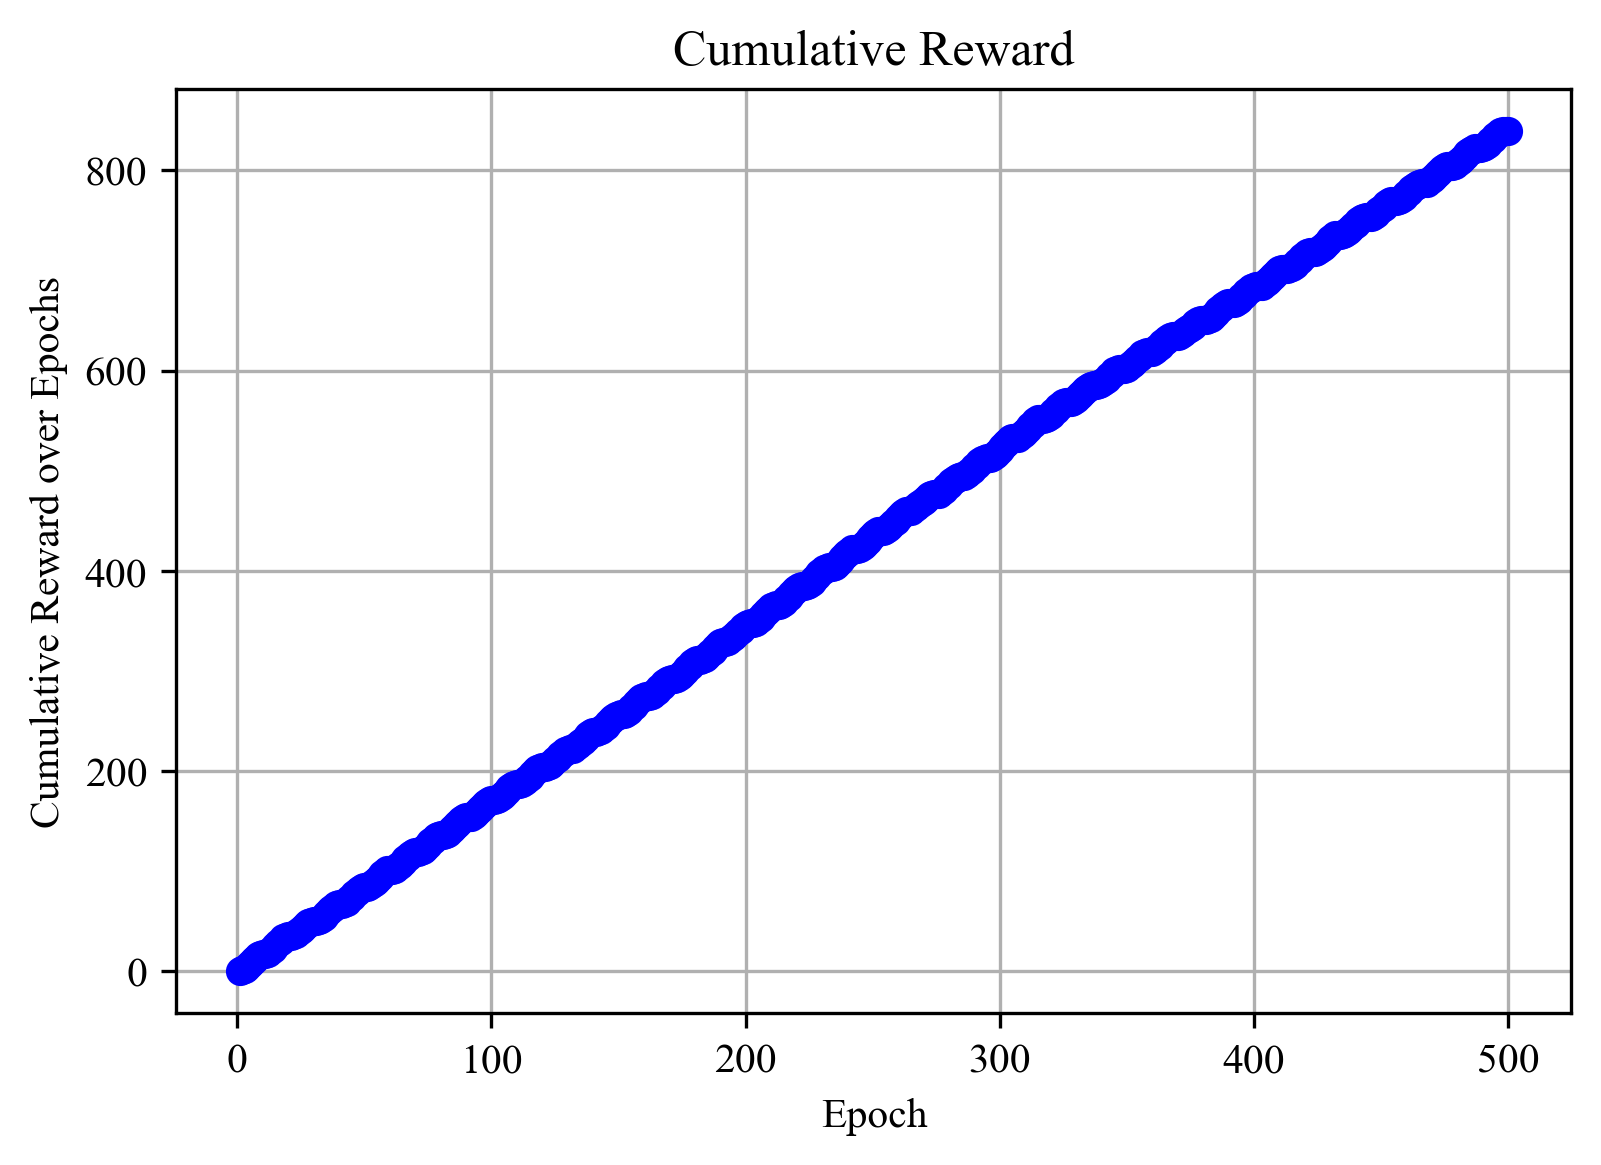

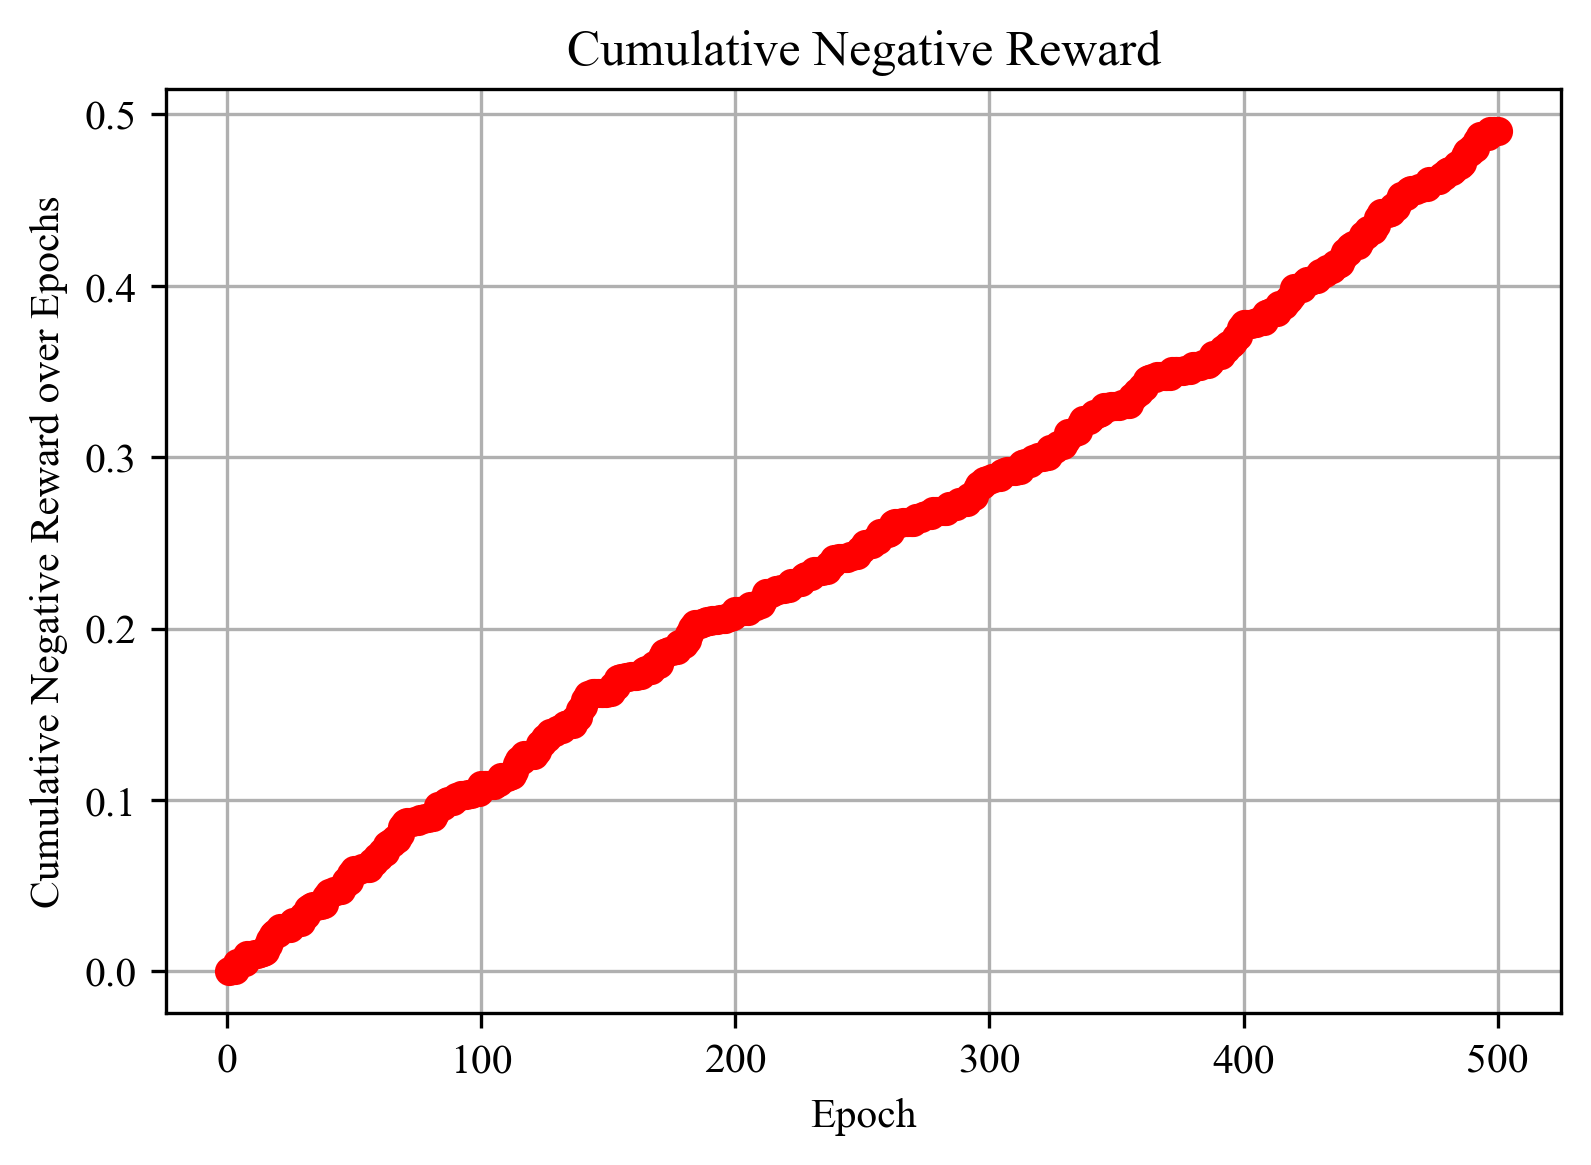

*******************%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%**********************
 Cumulative Reward: 839.1364799558867
*******************%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%**********************


In [ ]:
# plot 1 + RL plots
# Test



num_chosen_nothing_continually = 0
direction_to_tower_num = 1; #(1: tower1, 2: tower2)
last_selected_solar_v_index = 0
previous_tower_direction = 1
cumulative_rewards_list = []
cumulative_reward = 0
cumulative_negative_reward = 0
cumulative_negative_reward_list = []
rewards_at_this_epoch_list = []
num_steps = 500

agent = DQNAgent(state_size, action_size)
agent.load_weights_from_drive("Amir_thesis/69/5833.812230580179_DQN_model.weights.h5")



for i in range(num_steps):
        # Get the current state
    state = np.concatenate([
    solar_vectors_df_60min.iloc[i][:3].values.astype(float ),
    np.array([num_chosen_nothing_continually, direction_to_tower_num - 1], dtype=float)
        ])
        # state = np.array(solar_vectors_df_custon_min.iloc[i][:3].tolist() + [num_chosen_nothing_continually, direction_to_tower_num - 1]) # Your state representation  // -1 is for transforming direction_to_tower_num to 0,1
        # Select an action
        # print(state)
    action = agent.act(state)
    if action == 0:
        num_chosen_nothing_continually+=1

    elif action == 1:
        num_chosen_nothing_continually = 0
        direction_to_tower_num = 1
        last_selected_solar_v_index = i

    elif action == 2:
        num_chosen_nothing_continually = 0
        direction_to_tower_num = 2
        last_selected_solar_v_index = i

        # Perform the action in the environment and get the reward, next state, and done flag
    reward, negative_reward, previous_tower_direction = Calculate_reward(i , last_selected_solar_v_index , action, previous_tower_direction, time_step_in_hours ,solar_vectors_df_60min)  # Your reward function
    next_state = np.concatenate([
    solar_vectors_df_60min.iloc[i+1][:3].values.astype(float),
    np.array([num_chosen_nothing_continually, direction_to_tower_num - 1], dtype=float)
        ])
    done = 0  # Your done flag
    cumulative_reward += reward
    cumulative_negative_reward += negative_reward
    cumulative_rewards_list.append(cumulative_reward)
    cumulative_negative_reward_list.append(cumulative_negative_reward)



plot_reward(cumulative_rewards_list,'b',ylabel ='Cumulative Reward' ,xlabel = 'Epoch' , title ='Cumulative Reward over Epochs' )
plot_reward(cumulative_negative_reward_list, 'r', ylabel ='Cumulative Negative Reward' ,xlabel = 'Epoch' , title ='Cumulative Negative Reward over Epochs')
print("*******************%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%**********************")
print(f" Cumulative Reward: {cumulative_reward}")
print("*******************%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%**********************")
